In [ ]:
# Bladder Cancer Recurrence Survival AI

# Partha Pratim Ray, Sikkim University, India 14 may, 2026, parthapratimray1986@gmail.com, ppray@cus.ac.in

In [1]:
# ============================================================
# CELL 1: Install Required Packages
# ============================================================

!pip -q install --upgrade pip

!pip -q install \
    kaggle \
    kagglehub \
    lifelines \
    scikit-survival \
    pycox \
    torchtuples \
    scikit-learn \
    pandas \
    numpy \
    matplotlib \
    seaborn \
    scipy \
    statsmodels \
    shap \
    joblib \
    openpyxl \
    tabulate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 47.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
# ============================================================
# CELL 2: Imports and Global Plot Settings
# ============================================================

import os
import re
import json
import zipfile
import warnings
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    brier_score_loss,
)

from lifelines import (
    KaplanMeierFitter,
    NelsonAalenFitter,
    CoxPHFitter,
    CoxTimeVaryingFitter,
    WeibullFitter,
    LogNormalFitter,
    LogLogisticFitter,
    ExponentialFitter,
    WeibullAFTFitter,
    LogNormalAFTFitter,
    LogLogisticAFTFitter,
)

from lifelines.statistics import (
    multivariate_logrank_test,
    pairwise_logrank_test,
    proportional_hazard_test,
)

from lifelines.plotting import add_at_risk_counts, rmst_plot, qq_plot
from lifelines.utils import (
    concordance_index,
    restricted_mean_survival_time,
    k_fold_cross_validation,
)

from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import (
    concordance_index_censored,
    integrated_brier_score,
    cumulative_dynamic_auc,
    brier_score,
)

import torch
import torchtuples as tt
from pycox.models import CoxPH as PyCoxPH
from pycox.evaluation import EvalSurv

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Publication-grade plotting defaults
plt.rcParams.update({
    "figure.figsize": (8, 5.5),
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

OUTPUT_DIR = Path("outputs_bladder_survival")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MODEL_DIR = OUTPUT_DIR / "models"

for d in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Environment ready.")
print("CUDA available:", torch.cuda.is_available())

Environment ready.
CUDA available: True


In [3]:
# ============================================================
# CELL 2: Imports and Global Plot Settings
# ============================================================

import os
import re
import json
import zipfile
import warnings
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    brier_score_loss,
)

from lifelines import (
    KaplanMeierFitter,
    NelsonAalenFitter,
    CoxPHFitter,
    CoxTimeVaryingFitter,
    WeibullFitter,
    LogNormalFitter,
    LogLogisticFitter,
    ExponentialFitter,
    WeibullAFTFitter,
    LogNormalAFTFitter,
    LogLogisticAFTFitter,
)

from lifelines.statistics import (
    multivariate_logrank_test,
    pairwise_logrank_test,
    proportional_hazard_test,
)

from lifelines.plotting import add_at_risk_counts, rmst_plot, qq_plot
from lifelines.utils import (
    concordance_index,
    restricted_mean_survival_time,
    k_fold_cross_validation,
)

from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import (
    concordance_index_censored,
    integrated_brier_score,
    cumulative_dynamic_auc,
    brier_score,
)

import torch
import torchtuples as tt
from pycox.models import CoxPH as PyCoxPH
from pycox.evaluation import EvalSurv

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Publication-grade plotting defaults
plt.rcParams.update({
    "figure.figsize": (8, 5.5),
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

OUTPUT_DIR = Path("outputs_bladder_survival")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MODEL_DIR = OUTPUT_DIR / "models"

for d in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Environment ready.")
print("CUDA available:", torch.cuda.is_available())

Environment ready.
CUDA available: True


In [4]:
# ============================================================
# CELL 3: Kaggle Authentication
# ============================================================

from getpass import getpass

print("Paste your Kaggle API token when prompted.")
print("For safety, do not hard-code your token inside the notebook.")

kaggle_token = getpass("Enter Kaggle API token: ")

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/access_token", "w") as f:
    f.write(kaggle_token.strip())

os.chmod("/root/.kaggle/access_token", 0o600)

print("Kaggle token saved for this Colab session.")

Paste your Kaggle API token when prompted.
For safety, do not hard-code your token inside the notebook.
Enter Kaggle API token: ··········
Kaggle token saved for this Colab session.


In [5]:
# ============================================================
# CELL 4: Search Kaggle for Bladder Cancer Recurrence Dataset
# ============================================================

search_terms = [
    "bladder cancer recurrence",
    "bladder cancer recurrent event",
    "bladder cancer survival",
]

for term in search_terms:
    print("\n" + "=" * 90)
    print("Kaggle search:", term)
    print("=" * 90)
    !kaggle datasets list -s "$term"


Kaggle search: bladder cancer recurrence
ref                                                       title                                             size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------  ------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
utkarshx27/bladder-cancer-recurrences                     Bladder Cancer Recurrence Dataset                 6447  2023-05-09 11:45:52.070000           1417         34                1  
emmanueldjegou/counting-process-format-for-survival-data   Bladder Cancer Data for Survival Analysis         438  2022-07-26 17:33:53.797000            723         16        0.9411765  

Kaggle search: bladder cancer recurrent event
ref                                                       title                                             size  lastUpdated                 downloadCount  voteCount 

In [6]:
# ============================================================
# CELL 5: Download Dataset
# ============================================================
# Dataset selected from your description:
# Bladder Cancer Recurrence Dataset
# Expected files:
# bladder.csv, bladder1.csv, bladder2.csv

DATA_DIR = Path("data_bladder")
DATA_DIR.mkdir(exist_ok=True)

# Kaggle dataset slug from the earlier search result.
# If Kaggle changes slug, replace this line with the exact slug shown in CELL 4.
DATASET_SLUG = "utkarshx27/bladder-cancer-recurrences"

!kaggle datasets download -d "$DATASET_SLUG" -p "$DATA_DIR" --unzip

print("Downloaded files:")
for f in DATA_DIR.rglob("*"):
    print(f)

Dataset URL: https://www.kaggle.com/datasets/utkarshx27/bladder-cancer-recurrences
License(s): CC0-1.0
100% 6.30k/6.30k [00:00<00:00, 17.8MB/s]

Downloaded files:
data_bladder/bladder.csv
data_bladder/bladder1.csv
data_bladder/bladder2.csv


In [7]:
# ============================================================
# CELL 6: Load bladder.csv, bladder1.csv, bladder2.csv
# ============================================================

def read_csv_safely(path):
    try:
        return pd.read_csv(path)
    except Exception:
        return pd.read_csv(path, sep=None, engine="python")

bladder_path = DATA_DIR / "bladder.csv"
bladder1_path = DATA_DIR / "bladder1.csv"
bladder2_path = DATA_DIR / "bladder2.csv"

bladder = read_csv_safely(bladder_path)
bladder1 = read_csv_safely(bladder1_path)
bladder2 = read_csv_safely(bladder2_path)

print("bladder.csv shape:", bladder.shape)
print("bladder1.csv shape:", bladder1.shape)
print("bladder2.csv shape:", bladder2.shape)

display(bladder.head())
display(bladder1.head())
display(bladder2.head())

bladder.csv shape: (340, 8)
bladder1.csv shape: (294, 12)
bladder2.csv shape: (178, 9)


,Unnamed: 0,id,rx,number,size,stop,event,enum
0,1,1,1,1,3,1,0,1
1,2,1,1,1,3,1,0,2
2,3,1,1,1,3,1,0,3
3,4,1,1,1,3,1,0,4
4,5,2,1,2,1,4,0,1


,Unnamed: 0,id,treatment,number,size,recur,start,stop,status,rtumor,rsize,enum
0,1,1,placebo,1,1,0,0,0,3,.,.,1
1,2,2,placebo,1,3,0,0,1,3,.,.,1
2,3,3,placebo,2,1,0,0,4,0,.,.,1
3,4,4,placebo,1,1,0,0,7,0,.,.,1
4,5,5,placebo,5,1,0,0,10,3,.,.,1


,Unnamed: 0,id,rx,number,size,start,stop,event,enum
0,1,1,1,1,3,0,1,0,1
1,2,2,1,2,1,0,4,0,1
2,3,3,1,1,1,0,7,0,1
3,4,4,1,5,1,0,10,0,1
4,5,5,1,4,1,0,6,1,1


In [8]:
# ============================================================
# CELL 7: Clean Column Names and Inspect
# ============================================================

def clean_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace(".", "_", regex=False)
    )
    return df

bladder = clean_columns(bladder)
bladder1 = clean_columns(bladder1)
bladder2 = clean_columns(bladder2)

datasets = {
    "bladder": bladder,
    "bladder1": bladder1,
    "bladder2": bladder2,
}

for name, df in datasets.items():
    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    print(df.info())
    display(df.describe(include="all").T)


bladder
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   unnamed:_0  340 non-null    int64
 1   id          340 non-null    int64
 2   rx          340 non-null    int64
 3   number      340 non-null    int64
 4   size        340 non-null    int64
 5   stop        340 non-null    int64
 6   event       340 non-null    int64
 7   enum        340 non-null    int64
dtypes: int64(8)
memory usage: 21.4 KB
None


,count,mean,std,min,25%,50%,75%,max
unnamed:_0,340.0,170.500000,98.293777,1.0,85.75,170.5,255.25,340.0
id,340.0,43.000000,24.571850,1.0,22.00,43.0,64.00,85.0
rx,340.0,1.447059,0.497922,1.0,1.00,1.0,2.00,2.0
number,340.0,2.105882,1.751685,1.0,1.00,1.0,3.00,8.0
size,340.0,2.011765,1.436927,1.0,1.00,1.0,3.00,7.0
stop,340.0,25.064706,15.771841,1.0,12.00,25.0,37.00,59.0
event,340.0,0.329412,0.470692,0.0,0.00,0.0,1.00,1.0
enum,340.0,2.500000,1.119682,1.0,1.75,2.5,3.25,4.0



bladder1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   unnamed:_0  294 non-null    int64 
 1   id          294 non-null    int64 
 2   treatment   294 non-null    object
 3   number      294 non-null    int64 
 4   size        294 non-null    int64 
 5   recur       294 non-null    int64 
 6   start       294 non-null    int64 
 7   stop        294 non-null    int64 
 8   status      294 non-null    int64 
 9   rtumor      294 non-null    object
 10  rsize       294 non-null    object
 11  enum        294 non-null    int64 
dtypes: int64(9), object(3)
memory usage: 27.7+ KB
None


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
unnamed:_0,294.0,NaN,NaN,NaN,147.5,85.014705,1.0,74.25,147.5,220.75,294.0
id,294.0,NaN,NaN,NaN,60.085034,31.598531,1.0,34.0,61.5,87.0,118.0
treatment,294,3,placebo,128,NaN,NaN,NaN,NaN,NaN,NaN,NaN
number,294.0,NaN,NaN,NaN,2.37415,1.79385,1.0,1.0,2.0,3.0,8.0
size,294.0,NaN,NaN,NaN,1.993197,1.539011,1.0,1.0,1.0,3.0,8.0
recur,294.0,NaN,NaN,NaN,3.595238,3.022573,0.0,1.0,3.0,5.0,9.0
start,294.0,NaN,NaN,NaN,11.197279,13.733017,0.0,0.0,4.0,20.0,52.0
stop,294.0,NaN,NaN,NaN,23.795918,15.953618,0.0,10.0,23.0,36.0,64.0
status,294.0,NaN,NaN,NaN,0.931973,0.793832,0.0,0.0,1.0,1.0,3.0
rtumor,294,9,.,108,NaN,NaN,NaN,NaN,NaN,NaN,NaN



bladder2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   unnamed:_0  178 non-null    int64
 1   id          178 non-null    int64
 2   rx          178 non-null    int64
 3   number      178 non-null    int64
 4   size        178 non-null    int64
 5   start       178 non-null    int64
 6   stop        178 non-null    int64
 7   event       178 non-null    int64
 8   enum        178 non-null    int64
dtypes: int64(9)
memory usage: 12.6 KB
None


,count,mean,std,min,25%,50%,75%,max
unnamed:_0,178.0,89.500000,51.528309,1.0,45.25,89.5,133.75,178.0
id,178.0,43.000000,23.475676,1.0,24.00,42.5,64.00,85.0
rx,178.0,1.404494,0.492178,1.0,1.00,1.0,2.00,2.0
number,178.0,2.337079,1.825394,1.0,1.00,1.0,3.00,8.0
size,178.0,1.960674,1.431535,1.0,1.00,1.0,3.00,7.0
start,178.0,7.404494,10.342408,0.0,0.00,2.0,15.00,47.0
stop,178.0,21.337079,14.614785,1.0,9.00,20.0,29.00,59.0
event,178.0,0.629213,0.484378,0.0,0.00,1.0,1.00,1.0
enum,178.0,1.898876,1.036563,1.0,1.00,2.0,3.00,4.0


In [9]:
# ============================================================
# CELL 8: Harmonize Treatment Labels and Event Definitions
# ============================================================

def harmonize_treatment(df):
    df = df.copy()

    if "rx" in df.columns:
        df["treatment_label"] = df["rx"].map({
            1: "Placebo",
            2: "Thiotepa",
            "1": "Placebo",
            "2": "Thiotepa",
        }).fillna(df["rx"].astype(str))

    elif "treatment" in df.columns:
        df["treatment_label"] = (
            df["treatment"]
            .astype(str)
            .str.strip()
            .str.lower()
            .replace({
                "placebo": "Placebo",
                "pyridoxine": "Pyridoxine",
                "vitamin b6": "Pyridoxine",
                "thiotepa": "Thiotepa",
            })
        )
        df["treatment_label"] = df["treatment_label"].str.title()

    else:
        df["treatment_label"] = "Unknown"

    return df

bladder = harmonize_treatment(bladder)
bladder1 = harmonize_treatment(bladder1)
bladder2 = harmonize_treatment(bladder2)

# For recurrence analysis:
# status == 1 is recurrence.
# Other status values are censored for the recurrence endpoint.
for df in [bladder, bladder1, bladder2]:
    if "status" in df.columns:
        df["event_recurrence"] = (df["status"] == 1).astype(int)
    else:
        # bladder.csv often uses one row per possible recurrence.
        # If no status column exists, assume each row represents recurrence time.
        # Later aggregation will derive patient-level recurrence burden.
        df["event_recurrence"] = 1

display(bladder.head())
display(bladder1.head())
display(bladder2.head())

,unnamed:_0,id,rx,number,size,stop,event,enum,treatment_label,event_recurrence
0,1,1,1,1,3,1,0,1,Placebo,1
1,2,1,1,1,3,1,0,2,Placebo,1
2,3,1,1,1,3,1,0,3,Placebo,1
3,4,1,1,1,3,1,0,4,Placebo,1
4,5,2,1,2,1,4,0,1,Placebo,1


,unnamed:_0,id,treatment,number,size,recur,start,stop,status,rtumor,rsize,enum,treatment_label,event_recurrence
0,1,1,placebo,1,1,0,0,0,3,.,.,1,Placebo,0
1,2,2,placebo,1,3,0,0,1,3,.,.,1,Placebo,0
2,3,3,placebo,2,1,0,0,4,0,.,.,1,Placebo,0
3,4,4,placebo,1,1,0,0,7,0,.,.,1,Placebo,0
4,5,5,placebo,5,1,0,0,10,3,.,.,1,Placebo,0


,unnamed:_0,id,rx,number,size,start,stop,event,enum,treatment_label,event_recurrence
0,1,1,1,1,3,0,1,0,1,Placebo,1
1,2,2,1,2,1,0,4,0,1,Placebo,1
2,3,3,1,1,1,0,7,0,1,Placebo,1
3,4,4,1,5,1,0,10,0,1,Placebo,1
4,5,5,1,4,1,0,6,1,1,Placebo,1


In [10]:
# ============================================================
# CELL 9: Dataset Summary Table
# ============================================================

summary_rows = []

for name, df in {
    "bladder.csv": bladder,
    "bladder1.csv": bladder1,
    "bladder2.csv": bladder2,
}.items():
    row = {
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Unique patients": df["id"].nunique() if "id" in df.columns else np.nan,
        "Treatments": ", ".join(sorted(df["treatment_label"].dropna().astype(str).unique())),
        "Recurrence events": int(df["event_recurrence"].sum()) if "event_recurrence" in df.columns else np.nan,
    }
    if "stop" in df.columns:
        row["Max follow-up time"] = df["stop"].max()
        row["Median follow-up time"] = df["stop"].median()
    summary_rows.append(row)

dataset_summary = pd.DataFrame(summary_rows)
display(dataset_summary)

dataset_summary.to_csv(TABLE_DIR / "dataset_summary.csv", index=False)

,Dataset,Rows,Columns,Unique patients,Treatments,Recurrence events,Max follow-up time,Median follow-up time
0,bladder.csv,340,10,85,"Placebo, Thiotepa",340,59,25.0
1,bladder1.csv,294,14,118,"Placebo, Pyridoxine, Thiotepa",189,64,23.0
2,bladder2.csv,178,11,85,"Placebo, Thiotepa",178,59,20.0


In [11]:
# ============================================================
# CELL 10: Plot and Table Helper Functions
# ============================================================

def save_current_figure(filename):
    path_png = FIG_DIR / f"{filename}.png"
    path_pdf = FIG_DIR / f"{filename}.pdf"
    plt.tight_layout()
    plt.savefig(path_png, bbox_inches="tight")
    plt.savefig(path_pdf, bbox_inches="tight")
    print(f"Saved: {path_png}")
    print(f"Saved: {path_pdf}")

def show_copyable_table(df, title=None, filename=None, max_rows=100):
    if title:
        print("\n" + title)
        print("=" * len(title))
    display(df.head(max_rows))
    print("\nCopyable Markdown table:")
    print(df.head(max_rows).to_markdown(index=False))
    if filename:
        out = TABLE_DIR / filename
        df.to_csv(out, index=False)
        print(f"\nSaved table: {out}")

def treatment_order(series):
    preferred = ["Placebo", "Thiotepa", "Pyridoxine"]
    present = list(series.dropna().unique())
    ordered = [x for x in preferred if x in present]
    ordered += [x for x in present if x not in ordered]
    return ordered

Saved: outputs_bladder_survival/figures/treatment_distribution.png
Saved: outputs_bladder_survival/figures/treatment_distribution.pdf


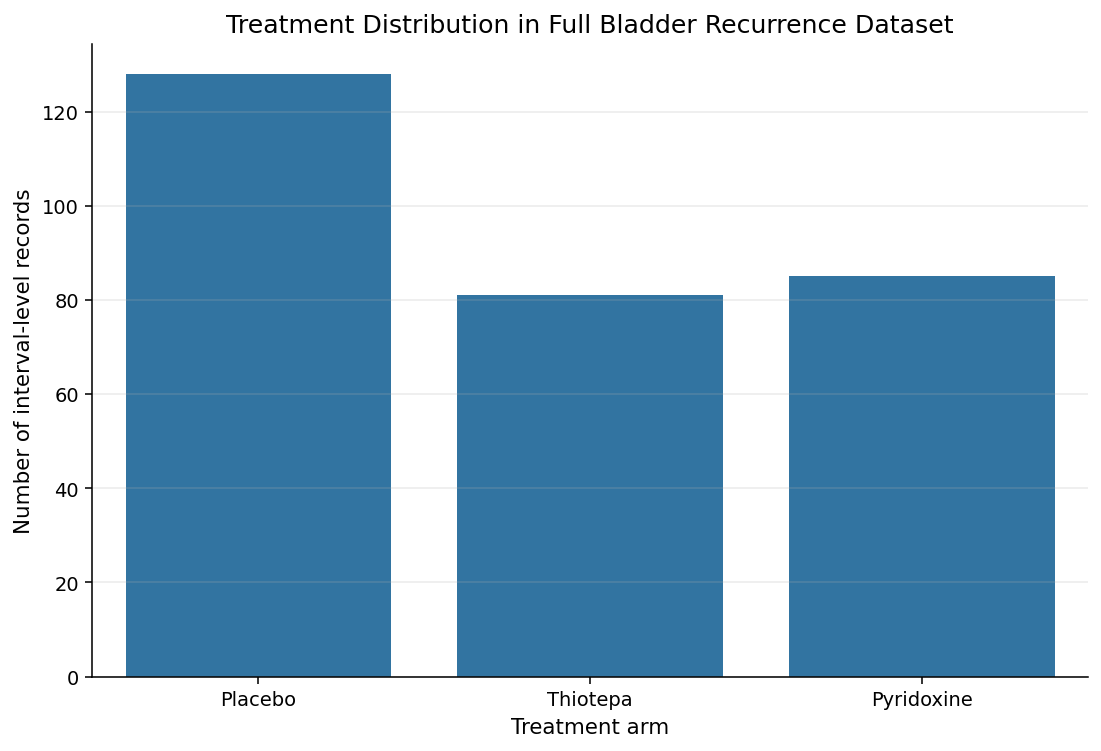


Copyable Table: Treatment Distribution


,Treatment,Record count,Percentage
0,Placebo,128,43.54
1,Pyridoxine,85,28.91
2,Thiotepa,81,27.55



Copyable Markdown table:
| Treatment   |   Record count |   Percentage |
|:------------|---------------:|-------------:|
| Placebo     |            128 |        43.54 |
| Pyridoxine  |             85 |        28.91 |
| Thiotepa    |             81 |        27.55 |

Saved table: outputs_bladder_survival/tables/treatment_distribution.csv


In [12]:
# ============================================================
# CELL 11: Baseline Clinical Feature Distributions
# ============================================================

eda_df = bladder1.copy()

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.countplot(data=eda_df, x="treatment_label", order=treatment_order(eda_df["treatment_label"]), ax=ax)
ax.set_title("Treatment Distribution in Full Bladder Recurrence Dataset")
ax.set_xlabel("Treatment arm")
ax.set_ylabel("Number of interval-level records")
save_current_figure("treatment_distribution")
plt.show()

tab_treatment = (
    eda_df["treatment_label"]
    .value_counts()
    .rename_axis("Treatment")
    .reset_index(name="Record count")
)
tab_treatment["Percentage"] = 100 * tab_treatment["Record count"] / tab_treatment["Record count"].sum()

show_copyable_table(
    tab_treatment.round(2),
    title="Copyable Table: Treatment Distribution",
    filename="treatment_distribution.csv"
)

Saved: outputs_bladder_survival/figures/distribution_number.png
Saved: outputs_bladder_survival/figures/distribution_number.pdf


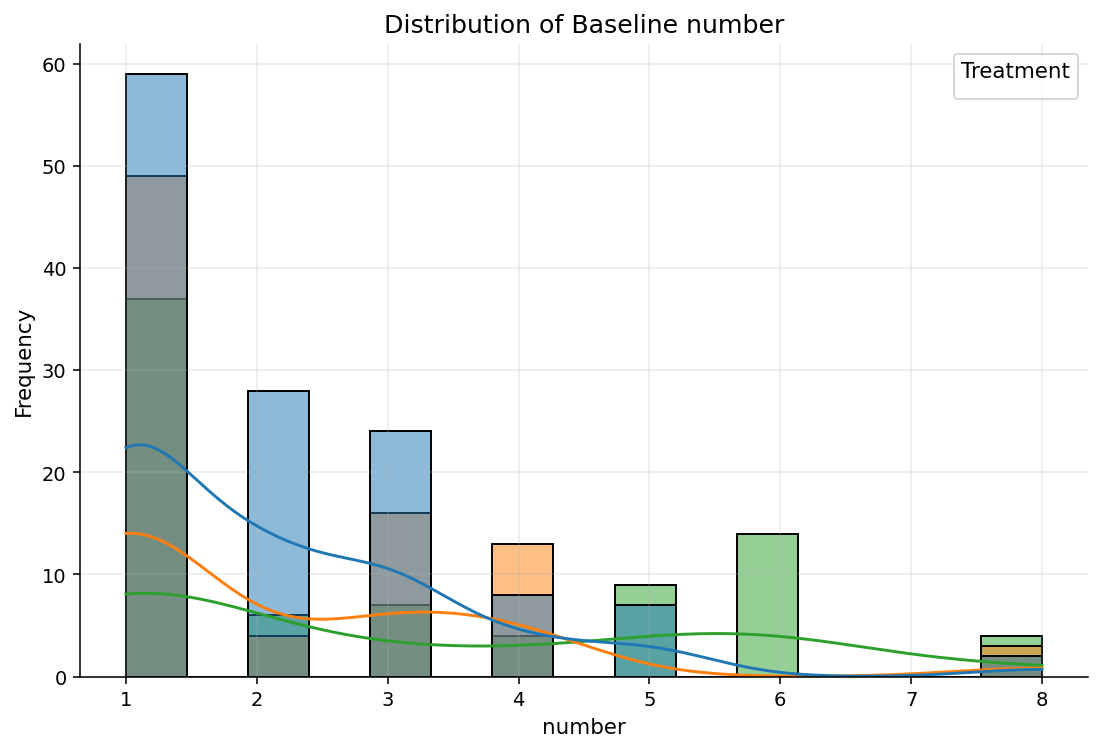


Copyable Table: Baseline number by Treatment


,Treatment,count,mean,std,median,min,max
0,Placebo,128,2.109,1.399,2.0,1,8
1,Pyridoxine,85,2.129,1.631,1.0,1,8
2,Thiotepa,81,3.049,2.291,2.0,1,8



Copyable Markdown table:
| Treatment   |   count |   mean |   std |   median |   min |   max |
|:------------|--------:|-------:|------:|---------:|------:|------:|
| Placebo     |     128 |  2.109 | 1.399 |        2 |     1 |     8 |
| Pyridoxine  |      85 |  2.129 | 1.631 |        1 |     1 |     8 |
| Thiotepa    |      81 |  3.049 | 2.291 |        2 |     1 |     8 |

Saved table: outputs_bladder_survival/tables/summary_number_by_treatment.csv
Saved: outputs_bladder_survival/figures/distribution_size.png
Saved: outputs_bladder_survival/figures/distribution_size.pdf


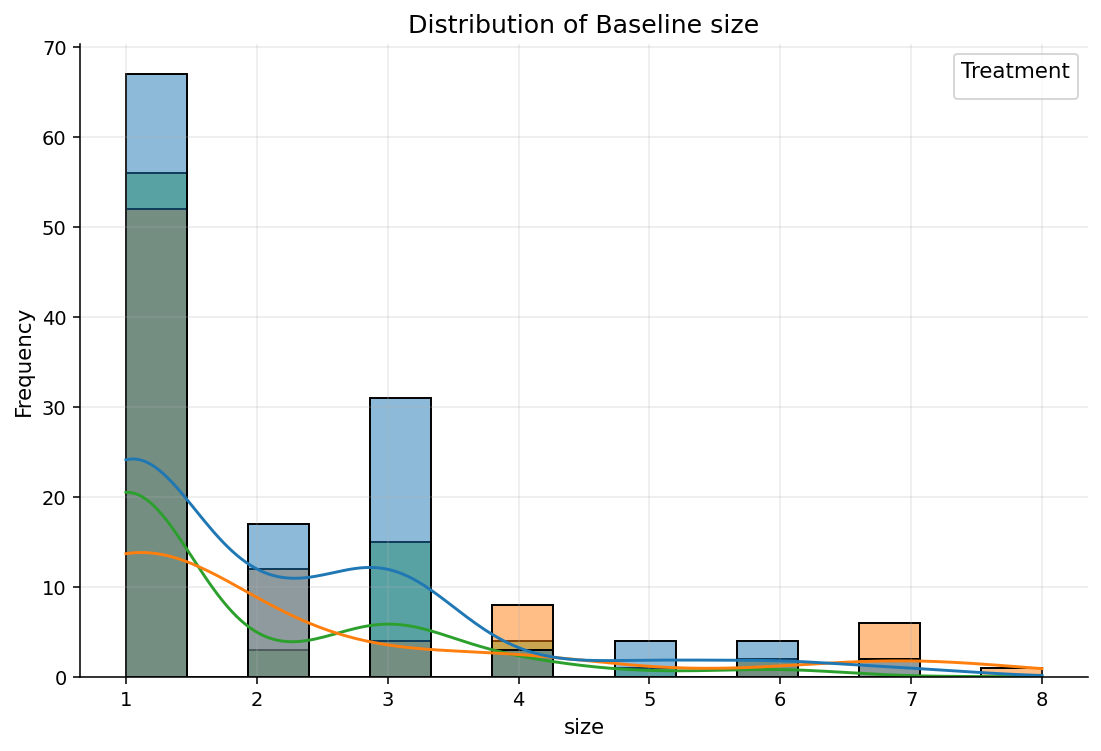


Copyable Table: Baseline size by Treatment


,Treatment,count,mean,std,median,min,max
0,Placebo,128,2.062,1.429,1.0,1,7
1,Pyridoxine,85,2.141,1.903,1.0,1,8
2,Thiotepa,81,1.728,1.235,1.0,1,6



Copyable Markdown table:
| Treatment   |   count |   mean |   std |   median |   min |   max |
|:------------|--------:|-------:|------:|---------:|------:|------:|
| Placebo     |     128 |  2.062 | 1.429 |        1 |     1 |     7 |
| Pyridoxine  |      85 |  2.141 | 1.903 |        1 |     1 |     8 |
| Thiotepa    |      81 |  1.728 | 1.235 |        1 |     1 |     6 |

Saved table: outputs_bladder_survival/tables/summary_size_by_treatment.csv


In [13]:
# ============================================================
# CELL 12: Baseline Tumor Burden Distribution
# ============================================================

feature_cols = [c for c in ["number", "size"] if c in bladder1.columns]

for col in feature_cols:
    fig, ax = plt.subplots(figsize=(8, 5.5))
    sns.histplot(data=bladder1, x=col, hue="treatment_label", kde=True, bins=15, ax=ax)
    ax.set_title(f"Distribution of Baseline {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.legend(title="Treatment")
    save_current_figure(f"distribution_{col}")
    plt.show()

    tab = (
        bladder1
        .groupby("treatment_label")[col]
        .agg(["count", "mean", "std", "median", "min", "max"])
        .reset_index()
        .rename(columns={"treatment_label": "Treatment"})
    )
    show_copyable_table(
        tab.round(3),
        title=f"Copyable Table: Baseline {col} by Treatment",
        filename=f"summary_{col}_by_treatment.csv"
    )

In [14]:
#Part A: Patient-level first recurrence analysis

# ============================================================
# CELL 13: Patient-Level First Recurrence Dataset
# ============================================================
# We use bladder1 because it contains the full dataset.
# Primary endpoint: time to first recurrence.
# Event: first status == 1 occurrence.
# Censoring: last observed stop time if no recurrence.

def make_first_recurrence_dataset(df):
    df = df.copy()
    df = df.sort_values(["id", "stop"])

    rows = []
    for pid, g in df.groupby("id"):
        g = g.sort_values("stop")
        baseline = g.iloc[0].to_dict()
        recurrence_rows = g[g["event_recurrence"] == 1]

        if len(recurrence_rows) > 0:
            first_event = recurrence_rows.iloc[0]
            duration = first_event["stop"]
            event = 1
        else:
            duration = g["stop"].max()
            event = 0

        rows.append({
            "id": pid,
            "duration": duration,
            "event": event,
            "treatment_label": baseline.get("treatment_label", "Unknown"),
            "number": baseline.get("number", np.nan),
            "size": baseline.get("size", np.nan),
            "total_recurrences": int(g["event_recurrence"].sum()),
            "max_followup": g["stop"].max(),
        })

    return pd.DataFrame(rows)

firstrec = make_first_recurrence_dataset(bladder1)

print(firstrec.shape)
display(firstrec.head())
display(firstrec.describe(include="all").T)

firstrec.to_csv(TABLE_DIR / "patient_level_first_recurrence_dataset.csv", index=False)

(118, 8)


,id,duration,event,treatment_label,number,size,total_recurrences,max_followup
0,1,0,0,Placebo,1,1,0,0
1,2,1,0,Placebo,1,3,0,1
2,3,4,0,Placebo,2,1,0,4
3,4,7,0,Placebo,1,1,0,7
4,5,10,0,Placebo,5,1,0,10


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,118.0,NaN,NaN,NaN,59.5,34.207699,1.0,30.25,59.5,88.75,118.0
duration,118.0,NaN,NaN,NaN,18.559322,17.271855,0.0,3.0,11.0,31.25,60.0
event,118.0,NaN,NaN,NaN,0.525424,0.501483,0.0,0.0,1.0,1.0,1.0
treatment_label,118,3,Placebo,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
number,118.0,NaN,NaN,NaN,2.067797,1.777008,1.0,1.0,1.0,3.0,8.0
size,118.0,NaN,NaN,NaN,2.016949,1.557903,1.0,1.0,1.0,3.0,8.0
total_recurrences,118.0,NaN,NaN,NaN,1.601695,2.302506,0.0,0.0,1.0,2.0,9.0
max_followup,118.0,NaN,NaN,NaN,31.389831,16.708171,0.0,18.25,31.5,44.0,64.0


In [15]:
# ============================================================
# CELL 14: Patient-Level Outcome Summary
# ============================================================

patient_summary = (
    firstrec
    .groupby("treatment_label")
    .agg(
        patients=("id", "nunique"),
        recurrence_events=("event", "sum"),
        recurrence_rate=("event", "mean"),
        median_time=("duration", "median"),
        mean_total_recurrences=("total_recurrences", "mean"),
        median_total_recurrences=("total_recurrences", "median"),
    )
    .reset_index()
    .rename(columns={"treatment_label": "Treatment"})
)

patient_summary["recurrence_rate_percent"] = patient_summary["recurrence_rate"] * 100

show_copyable_table(
    patient_summary.round(3),
    title="Copyable Table: Patient-Level Outcome Summary",
    filename="patient_level_outcome_summary.csv"
)


Copyable Table: Patient-Level Outcome Summary


,Treatment,patients,recurrence_events,recurrence_rate,median_time,mean_total_recurrences,median_total_recurrences,recurrence_rate_percent
0,Placebo,48,29,0.604,10.0,1.812,1.0,60.417
1,Pyridoxine,32,15,0.469,8.0,1.781,0.0,46.875
2,Thiotepa,38,18,0.474,17.5,1.184,0.0,47.368



Copyable Markdown table:
| Treatment   |   patients |   recurrence_events |   recurrence_rate |   median_time |   mean_total_recurrences |   median_total_recurrences |   recurrence_rate_percent |
|:------------|-----------:|--------------------:|------------------:|--------------:|-------------------------:|---------------------------:|--------------------------:|
| Placebo     |         48 |                  29 |             0.604 |          10   |                    1.812 |                          1 |                    60.417 |
| Pyridoxine  |         32 |                  15 |             0.469 |           8   |                    1.781 |                          0 |                    46.875 |
| Thiotepa    |         38 |                  18 |             0.474 |          17.5 |                    1.184 |                          0 |                    47.368 |

Saved table: outputs_bladder_survival/tables/patient_level_outcome_summary.csv


Saved: outputs_bladder_survival/figures/kaplan_meier_by_treatment.png
Saved: outputs_bladder_survival/figures/kaplan_meier_by_treatment.pdf


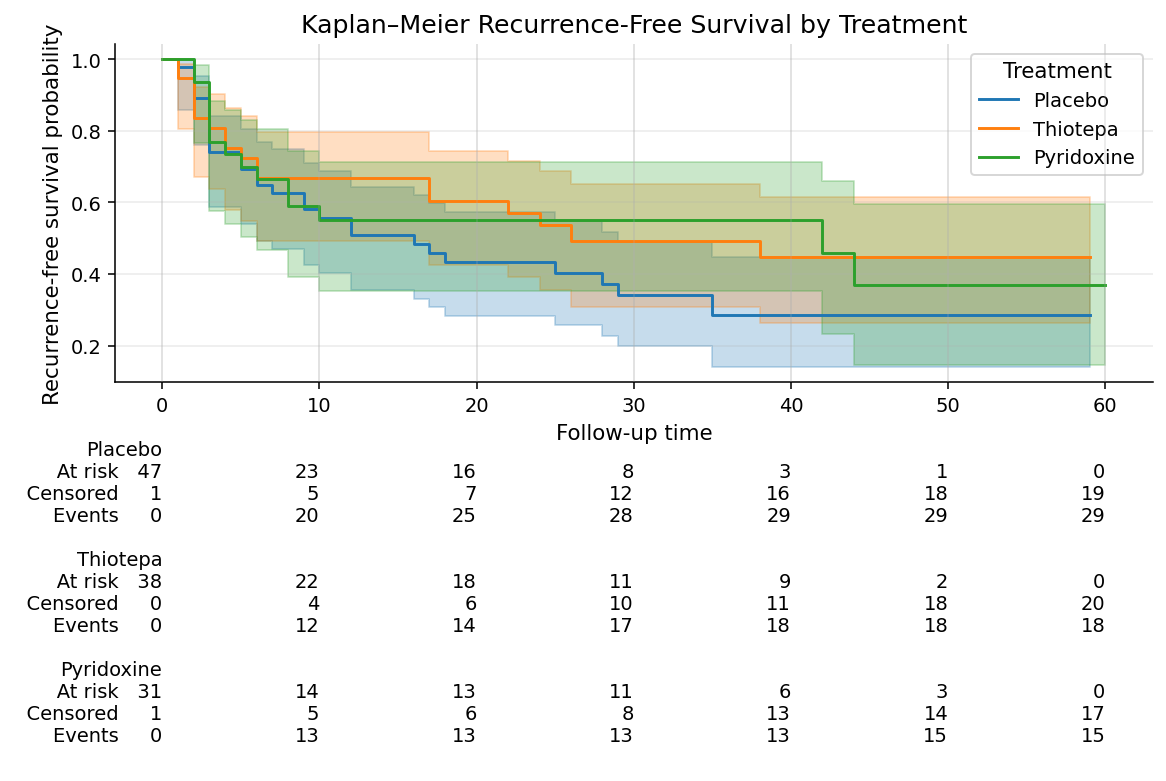


Copyable Table: KM Survival Probabilities


,Treatment,Time,Recurrence-free survival
0,Placebo,3,0.7395
1,Placebo,6,0.6498
2,Placebo,9,0.5810
3,Placebo,12,0.5092
4,Placebo,18,0.4328
5,Placebo,24,0.4328
6,Placebo,36,0.2849
7,Placebo,48,0.2849
8,Thiotepa,3,0.8080
9,Thiotepa,6,0.6687



Copyable Markdown table:
| Treatment   |   Time |   Recurrence-free survival |
|:------------|-------:|---------------------------:|
| Placebo     |      3 |                     0.7395 |
| Placebo     |      6 |                     0.6498 |
| Placebo     |      9 |                     0.581  |
| Placebo     |     12 |                     0.5092 |
| Placebo     |     18 |                     0.4328 |
| Placebo     |     24 |                     0.4328 |
| Placebo     |     36 |                     0.2849 |
| Placebo     |     48 |                     0.2849 |
| Thiotepa    |      3 |                     0.808  |
| Thiotepa    |      6 |                     0.6687 |
| Thiotepa    |      9 |                     0.6687 |
| Thiotepa    |     12 |                     0.6687 |
| Thiotepa    |     18 |                     0.605  |
| Thiotepa    |     24 |                     0.5357 |
| Thiotepa    |     36 |                     0.4911 |
| Thiotepa    |     48 |                     0.4464 |
| 

In [16]:
# ============================================================
# CELL 15: Kaplan-Meier Recurrence-Free Survival by Treatment
# ============================================================

kmf_models = {}

fig, ax = plt.subplots(figsize=(8.5, 6))

for trt in treatment_order(firstrec["treatment_label"]):
    g = firstrec[firstrec["treatment_label"] == trt]
    kmf = KaplanMeierFitter()
    kmf.fit(g["duration"], event_observed=g["event"], label=trt)
    kmf.plot_survival_function(ax=ax, ci_show=True)
    kmf_models[trt] = kmf

ax.set_title("Kaplan–Meier Recurrence-Free Survival by Treatment")
ax.set_xlabel("Follow-up time")
ax.set_ylabel("Recurrence-free survival probability")
ax.legend(title="Treatment")
add_at_risk_counts(*kmf_models.values(), ax=ax)
save_current_figure("kaplan_meier_by_treatment")
plt.show()

# Copyable survival probabilities at selected times
time_points = np.array([3, 6, 9, 12, 18, 24, 36, 48])
surv_rows = []

for trt, kmf in kmf_models.items():
    surv_probs = kmf.survival_function_at_times(time_points).values
    for t, s in zip(time_points, surv_probs):
        surv_rows.append({
            "Treatment": trt,
            "Time": t,
            "Recurrence-free survival": s,
        })

surv_table = pd.DataFrame(surv_rows)

show_copyable_table(
    surv_table.round(4),
    title="Copyable Table: KM Survival Probabilities",
    filename="km_survival_probabilities_by_treatment.csv"
)

In [17]:
# ============================================================
# CELL 16: Logrank and Weighted Logrank Tests
# ============================================================

logrank_results = []

for weighting in [None, "wilcoxon", "tarone-ware", "peto"]:
    if weighting is None:
        result = multivariate_logrank_test(
            firstrec["duration"],
            firstrec["treatment_label"],
            firstrec["event"],
        )
        test_name = "Logrank"
    else:
        result = multivariate_logrank_test(
            firstrec["duration"],
            firstrec["treatment_label"],
            firstrec["event"],
            weightings=weighting,
        )
        test_name = f"Weighted logrank: {weighting}"

    logrank_results.append({
        "Test": test_name,
        "Test statistic": result.test_statistic,
        "p-value": result.p_value,
        "Degrees of freedom": result.degrees_of_freedom,
    })

logrank_table = pd.DataFrame(logrank_results)

show_copyable_table(
    logrank_table.round(5),
    title="Copyable Table: Logrank Tests by Treatment",
    filename="logrank_tests.csv"
)


Copyable Table: Logrank Tests by Treatment


,Test,Test statistic,p-value,Degrees of freedom
0,Logrank,2.12063,0.34635,2
1,Weighted logrank: wilcoxon,0.98590,0.61082,2
2,Weighted logrank: tarone-ware,1.48690,0.47547,2
3,Weighted logrank: peto,1.29727,0.52276,2



Copyable Markdown table:
| Test                          |   Test statistic |   p-value |   Degrees of freedom |
|:------------------------------|-----------------:|----------:|---------------------:|
| Logrank                       |          2.12063 |   0.34635 |                    2 |
| Weighted logrank: wilcoxon    |          0.9859  |   0.61082 |                    2 |
| Weighted logrank: tarone-ware |          1.4869  |   0.47547 |                    2 |
| Weighted logrank: peto        |          1.29727 |   0.52276 |                    2 |

Saved table: outputs_bladder_survival/tables/logrank_tests.csv


In [18]:
# ============================================================
# CELL 16: Logrank and Weighted Logrank Tests
# ============================================================

logrank_results = []

for weighting in [None, "wilcoxon", "tarone-ware", "peto"]:
    if weighting is None:
        result = multivariate_logrank_test(
            firstrec["duration"],
            firstrec["treatment_label"],
            firstrec["event"],
        )
        test_name = "Logrank"
    else:
        result = multivariate_logrank_test(
            firstrec["duration"],
            firstrec["treatment_label"],
            firstrec["event"],
            weightings=weighting,
        )
        test_name = f"Weighted logrank: {weighting}"

    logrank_results.append({
        "Test": test_name,
        "Test statistic": result.test_statistic,
        "p-value": result.p_value,
        "Degrees of freedom": result.degrees_of_freedom,
    })

logrank_table = pd.DataFrame(logrank_results)

show_copyable_table(
    logrank_table.round(5),
    title="Copyable Table: Logrank Tests by Treatment",
    filename="logrank_tests.csv"
)


Copyable Table: Logrank Tests by Treatment


,Test,Test statistic,p-value,Degrees of freedom
0,Logrank,2.12063,0.34635,2
1,Weighted logrank: wilcoxon,0.98590,0.61082,2
2,Weighted logrank: tarone-ware,1.48690,0.47547,2
3,Weighted logrank: peto,1.29727,0.52276,2



Copyable Markdown table:
| Test                          |   Test statistic |   p-value |   Degrees of freedom |
|:------------------------------|-----------------:|----------:|---------------------:|
| Logrank                       |          2.12063 |   0.34635 |                    2 |
| Weighted logrank: wilcoxon    |          0.9859  |   0.61082 |                    2 |
| Weighted logrank: tarone-ware |          1.4869  |   0.47547 |                    2 |
| Weighted logrank: peto        |          1.29727 |   0.52276 |                    2 |

Saved table: outputs_bladder_survival/tables/logrank_tests.csv



Copyable Table: Restricted Mean Recurrence-Free Survival Time


,Treatment,RMST time horizon,Restricted mean recurrence-free time
0,Placebo,48,21.9931
1,Thiotepa,48,28.0208
2,Pyridoxine,48,27.6971



Copyable Markdown table:
| Treatment   |   RMST time horizon |   Restricted mean recurrence-free time |
|:------------|--------------------:|---------------------------------------:|
| Placebo     |                  48 |                                21.9931 |
| Thiotepa    |                  48 |                                28.0208 |
| Pyridoxine  |                  48 |                                27.6971 |

Saved table: outputs_bladder_survival/tables/rmst_by_treatment.csv
Saved: outputs_bladder_survival/figures/rmst_Placebo.png
Saved: outputs_bladder_survival/figures/rmst_Placebo.pdf


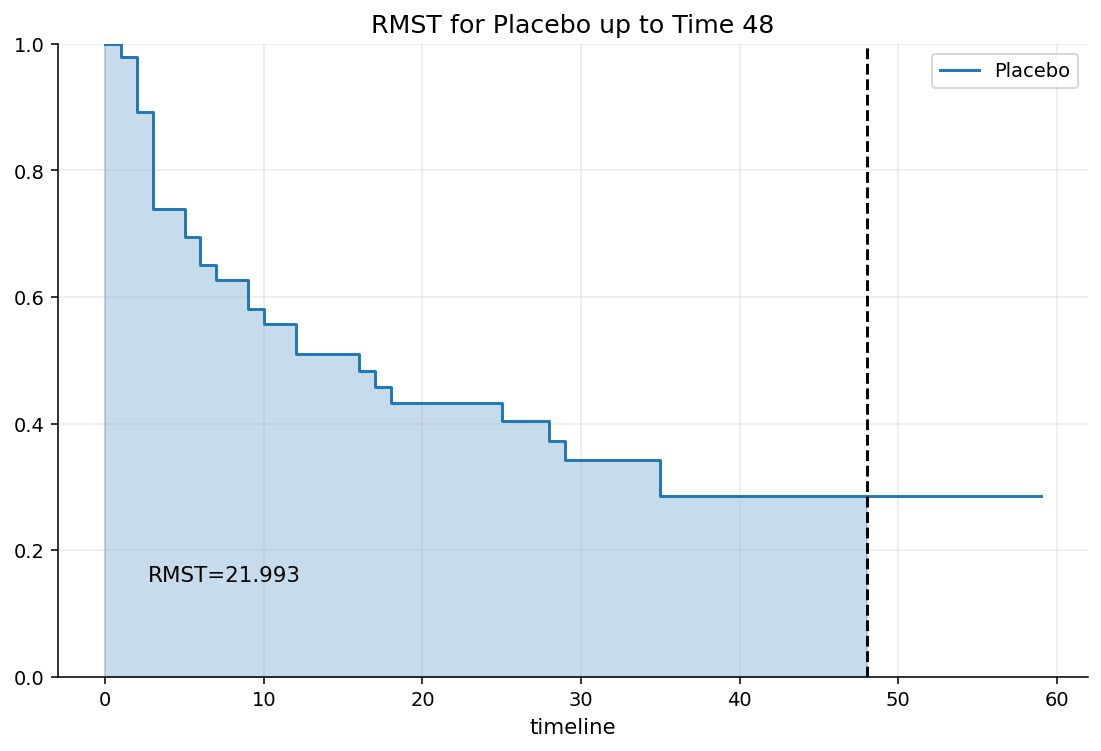

Saved: outputs_bladder_survival/figures/rmst_Thiotepa.png
Saved: outputs_bladder_survival/figures/rmst_Thiotepa.pdf


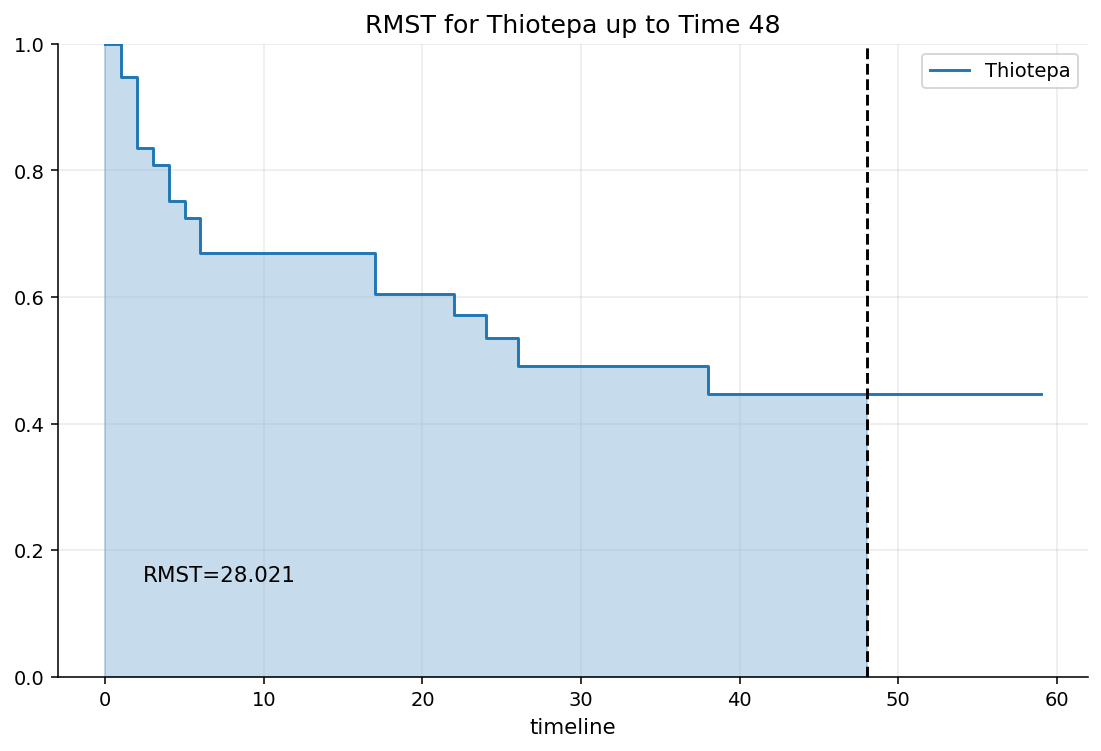

Saved: outputs_bladder_survival/figures/rmst_Pyridoxine.png
Saved: outputs_bladder_survival/figures/rmst_Pyridoxine.pdf


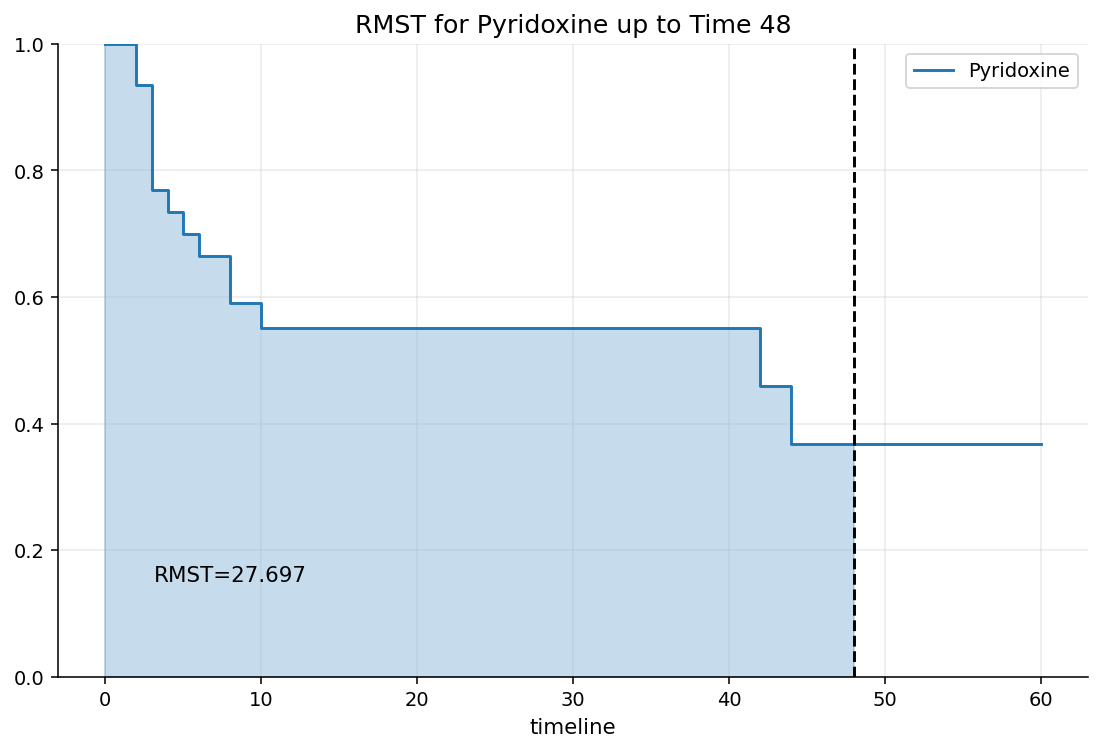

In [19]:
# ============================================================
# CELL 17: Restricted Mean Recurrence-Free Survival Time
# ============================================================

time_limit = min(48, firstrec["duration"].max())

rmst_rows = []

for trt, kmf in kmf_models.items():
    rmst = restricted_mean_survival_time(kmf, t=time_limit)
    rmst_rows.append({
        "Treatment": trt,
        "RMST time horizon": time_limit,
        "Restricted mean recurrence-free time": rmst,
    })

rmst_table = pd.DataFrame(rmst_rows)

show_copyable_table(
    rmst_table.round(4),
    title="Copyable Table: Restricted Mean Recurrence-Free Survival Time",
    filename="rmst_by_treatment.csv"
)

# Plot RMST for each treatment separately
for trt, kmf in kmf_models.items():
    fig, ax = plt.subplots(figsize=(8, 5.5))
    rmst_plot(kmf, t=time_limit, ax=ax)
    ax.set_title(f"RMST for {trt} up to Time {time_limit}")
    save_current_figure(f"rmst_{trt}")
    plt.show()

In [20]:
# ============================================================
# CELL 18: Cox Proportional Hazards Model
# ============================================================

cox_df = firstrec[["duration", "event", "treatment_label", "number", "size"]].dropna().copy()
cox_df = pd.get_dummies(cox_df, columns=["treatment_label"], drop_first=True)

print("CoxPH modeling dataset shape:", cox_df.shape)
display(cox_df.head())

cph = CoxPHFitter()
cph.fit(cox_df, duration_col="duration", event_col="event", robust=True)

cph.print_summary()

cox_summary = cph.summary.reset_index().rename(columns={"covariate": "Variable"})

show_copyable_table(
    cox_summary.round(5),
    title="Copyable Table: CoxPH Model Summary",
    filename="coxph_summary.csv"
)

CoxPH modeling dataset shape: (118, 6)


,duration,event,number,size,treatment_label_Pyridoxine,treatment_label_Thiotepa
0,0,0,1,1,False,False
1,1,0,1,3,False,False
2,4,0,2,1,False,False
3,7,0,1,1,False,False
4,10,0,5,1,False,False


<lifelines.CoxPHFitter: fitted with 118 total observations, 56 right-censored observations>
             duration col = 'duration'
                event col = 'event'
          robust variance = True
      baseline estimation = breslow
   number of observations = 118
number of events observed = 62
   partial log-likelihood = -255.88
         time fit was run = 2026-05-14 11:49:44 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                   
number                      0.25      1.29      0.06            0.14            0.37                1.15                1.45
size                        0.06      1.06      0.08           -0.10            0.21                0.91                1.24
treatment_label_Pyridoxine -0.34      0.71      0.31           -0.94            0.26                0.39                1.30
treatment_label_Thiotepa   -0.55      0.58      0.31           -1.16            0.06                0.31                1.06

                            cmp to     z      p  -log2(p)
covariate                                                
number                        0.00  4.27 <0.005     15.63
size                          0.00  0.74   0.46      1.13
treatment_label_Pyridoxine    0.00 -1.11   0.27      1.91
treatment_label_Thiotepa      0.00 -1.77   0.08      3.71
---
Concordance = 0.64
Partial AIC = 519.75
log-likelihood ratio test = 14.94 on 4 df
-log2(p) of ll-ratio test = 7.69


Copyable Table: CoxPH Model Summary


,Variable,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
0,number,0.25249,1.28723,0.05917,0.13652,0.36846,1.14628,1.44551,0.0,4.26729,0.00002,15.62514
1,size,0.05892,1.06069,0.07926,-0.09642,0.21426,0.90809,1.23895,0.0,0.74344,0.45721,1.12906
2,treatment_label_Pyridoxine,-0.34130,0.71085,0.30674,-0.94249,0.25989,0.38966,1.29679,0.0,-1.11268,0.26585,1.91133
3,treatment_label_Thiotepa,-0.55105,0.57634,0.31116,-1.16092,0.05882,0.31320,1.06058,0.0,-1.77094,0.07657,3.70706



Copyable Markdown table:
| Variable                   |     coef |   exp(coef) |   se(coef) |   coef lower 95% |   coef upper 95% |   exp(coef) lower 95% |   exp(coef) upper 95% |   cmp to |        z |       p |   -log2(p) |
|:---------------------------|---------:|------------:|-----------:|-----------------:|-----------------:|----------------------:|----------------------:|---------:|---------:|--------:|-----------:|
| number                     |  0.25249 |     1.28723 |    0.05917 |          0.13652 |          0.36846 |               1.14628 |               1.44551 |        0 |  4.26729 | 2e-05   |   15.6251  |
| size                       |  0.05892 |     1.06069 |    0.07926 |         -0.09642 |          0.21426 |               0.90809 |               1.23895 |        0 |  0.74344 | 0.45721 |    1.12906 |
| treatment_label_Pyridoxine | -0.3413  |     0.71085 |    0.30674 |         -0.94249 |          0.25989 |               0.38966 |               1.29679 |        0 | -1.11268

Saved: outputs_bladder_survival/figures/coxph_hazard_ratio_forest_plot.png
Saved: outputs_bladder_survival/figures/coxph_hazard_ratio_forest_plot.pdf


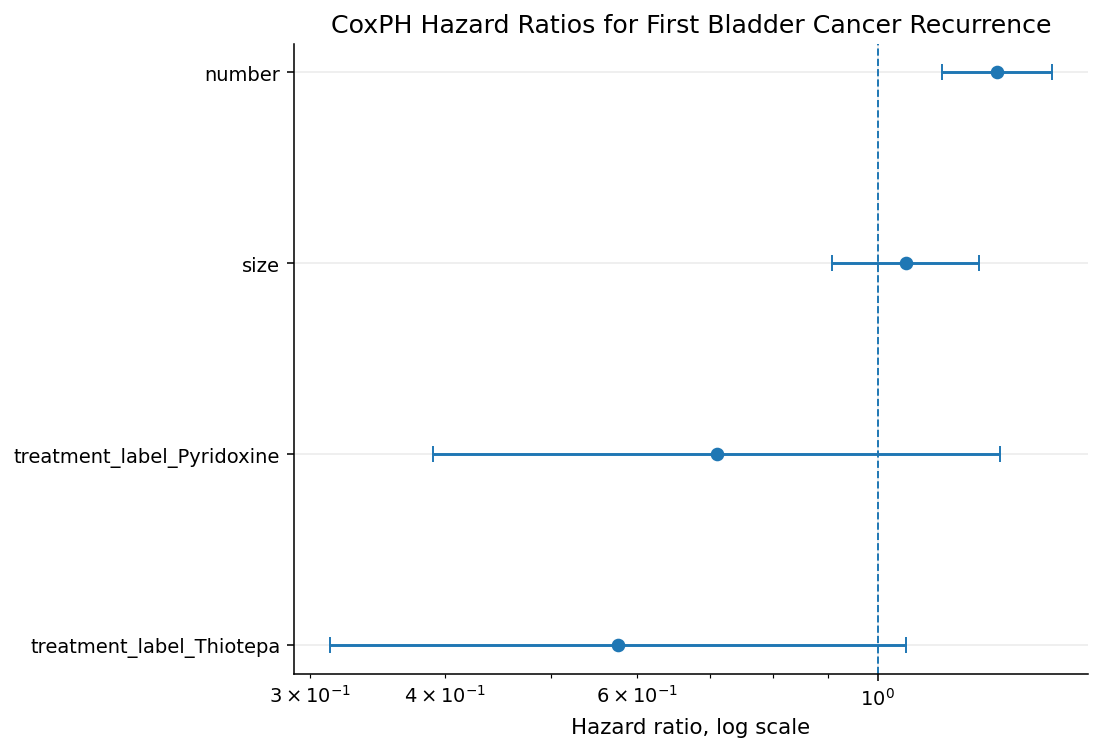


Copyable Table: Hazard Ratios with 95% CI


,Variable,HR,HR_lower_95,HR_upper_95,p
0,number,1.28723,1.14628,1.44551,0.00002
1,size,1.06069,0.90809,1.23895,0.45721
2,treatment_label_Pyridoxine,0.71085,0.38966,1.29679,0.26585
3,treatment_label_Thiotepa,0.57634,0.31320,1.06058,0.07657



Copyable Markdown table:
| Variable                   |      HR |   HR_lower_95 |   HR_upper_95 |       p |
|:---------------------------|--------:|--------------:|--------------:|--------:|
| number                     | 1.28723 |       1.14628 |       1.44551 | 2e-05   |
| size                       | 1.06069 |       0.90809 |       1.23895 | 0.45721 |
| treatment_label_Pyridoxine | 0.71085 |       0.38966 |       1.29679 | 0.26585 |
| treatment_label_Thiotepa   | 0.57634 |       0.3132  |       1.06058 | 0.07657 |

Saved table: outputs_bladder_survival/tables/coxph_hazard_ratios.csv


In [22]:
# ============================================================
# CELL 19: Hazard Ratio Forest Plot
# ============================================================

hr_table = cox_summary.copy()
hr_table["HR"] = np.exp(hr_table["coef"])
hr_table["HR_lower_95"] = np.exp(hr_table["coef lower 95%"])
hr_table["HR_upper_95"] = np.exp(hr_table["coef upper 95%"])

plot_df = hr_table.sort_values("HR")

fig, ax = plt.subplots(figsize=(8, 5.5))

y_pos = np.arange(len(plot_df))
ax.errorbar(
    plot_df["HR"],
    y_pos,
    xerr=[
        plot_df["HR"] - plot_df["HR_lower_95"],
        plot_df["HR_upper_95"] - plot_df["HR"]
    ],
    fmt="o",
    capsize=4,
)

ax.axvline(1.0, linestyle="--", linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["Variable"])
ax.set_xscale("log")
ax.set_xlabel("Hazard ratio, log scale")
ax.set_title("CoxPH Hazard Ratios for First Bladder Cancer Recurrence")
save_current_figure("coxph_hazard_ratio_forest_plot")
plt.show()

show_copyable_table(
    hr_table[["Variable", "HR", "HR_lower_95", "HR_upper_95", "p"]].round(5),
    title="Copyable Table: Hazard Ratios with 95% CI",
    filename="coxph_hazard_ratios.csv"
)


Copyable Table: Proportional Hazards Test


,Variable,test_statistic,p,-log2(p)
0,number,0.06878,0.79313,0.33438
1,size,0.55314,0.45704,1.12961
2,treatment_label_Pyridoxine,0.03414,0.85342,0.22868
3,treatment_label_Thiotepa,0.33859,0.56064,0.83485



Copyable Markdown table:
| Variable                   |   test_statistic |       p |   -log2(p) |
|:---------------------------|-----------------:|--------:|-----------:|
| number                     |          0.06878 | 0.79313 |    0.33438 |
| size                       |          0.55314 | 0.45704 |    1.12961 |
| treatment_label_Pyridoxine |          0.03414 | 0.85342 |    0.22868 |
| treatment_label_Thiotepa   |          0.33859 | 0.56064 |    0.83485 |

Saved table: outputs_bladder_survival/tables/proportional_hazards_test.csv

   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.7931)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9408)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.4570)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3873)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8534)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5941)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.5606)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2379)'>]]

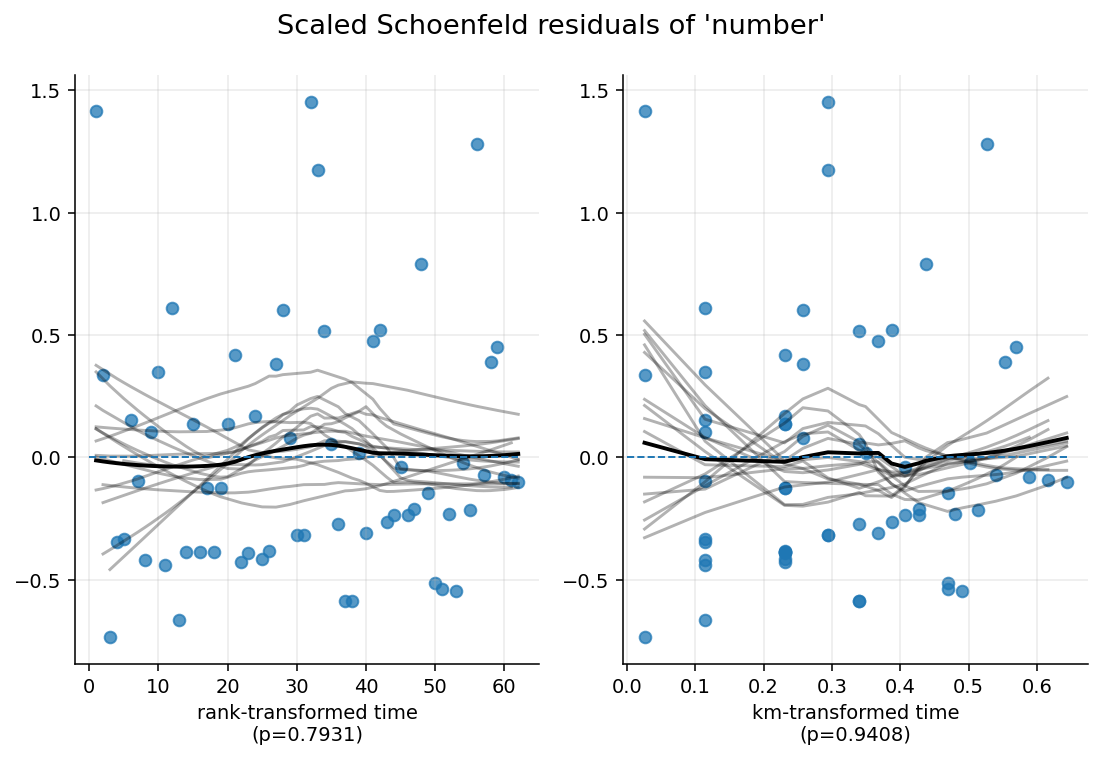

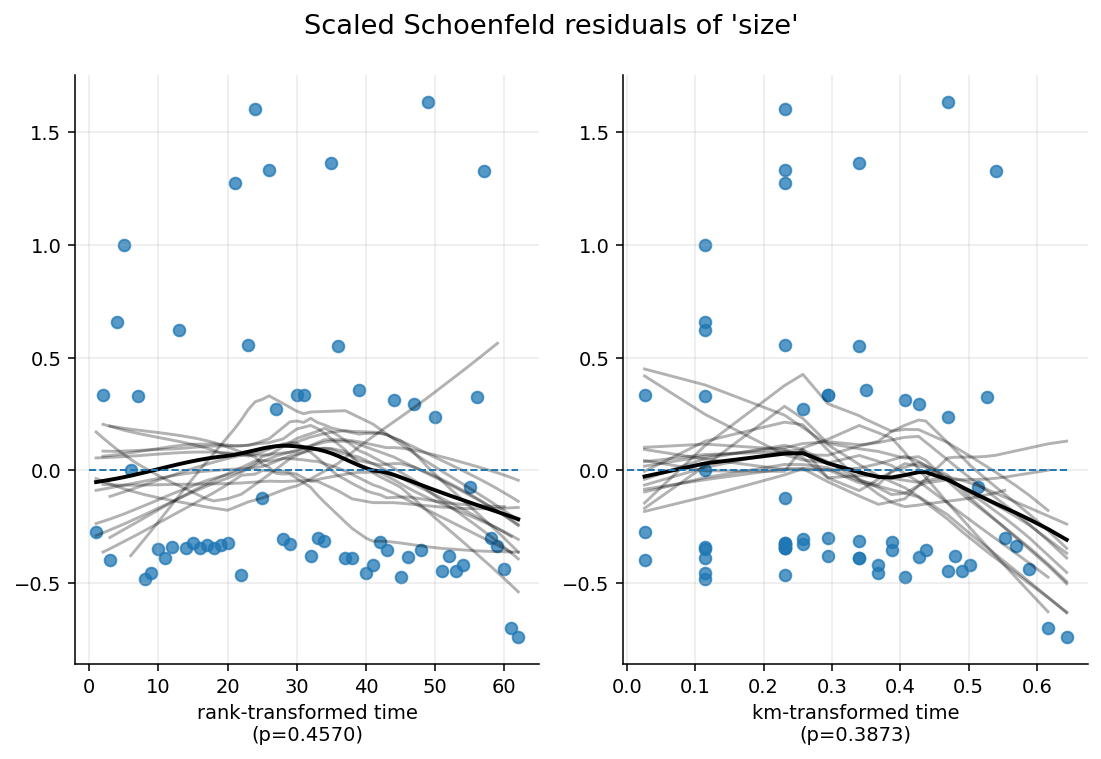

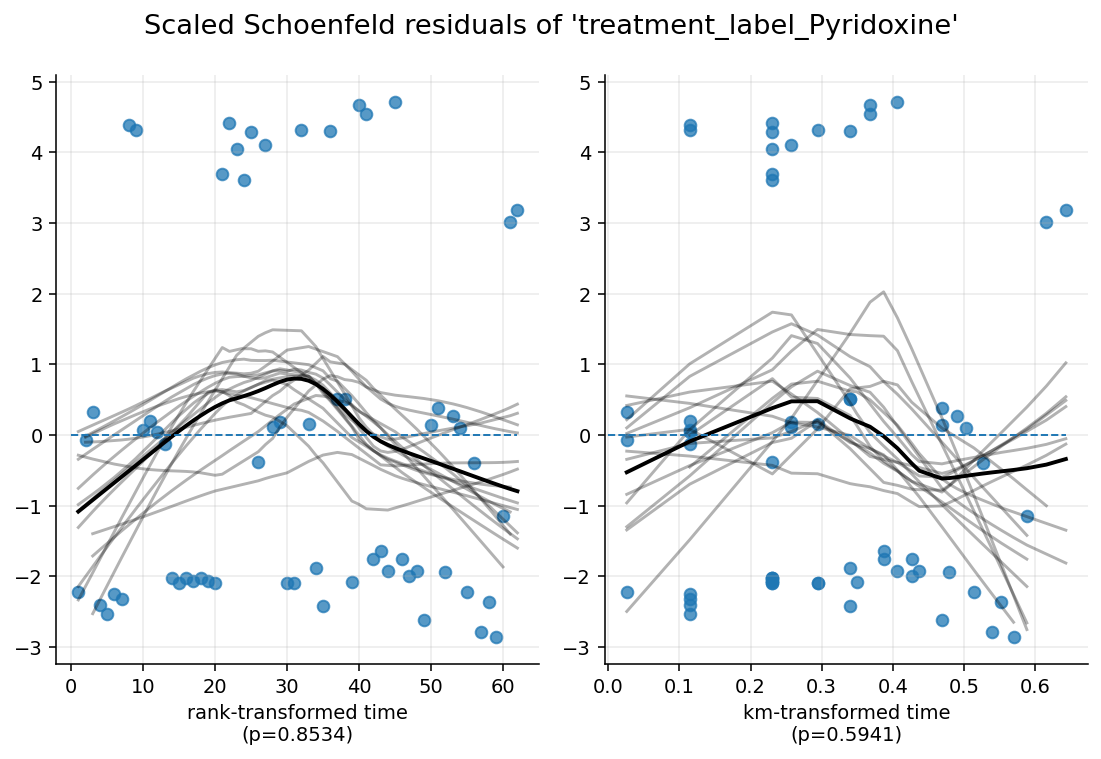

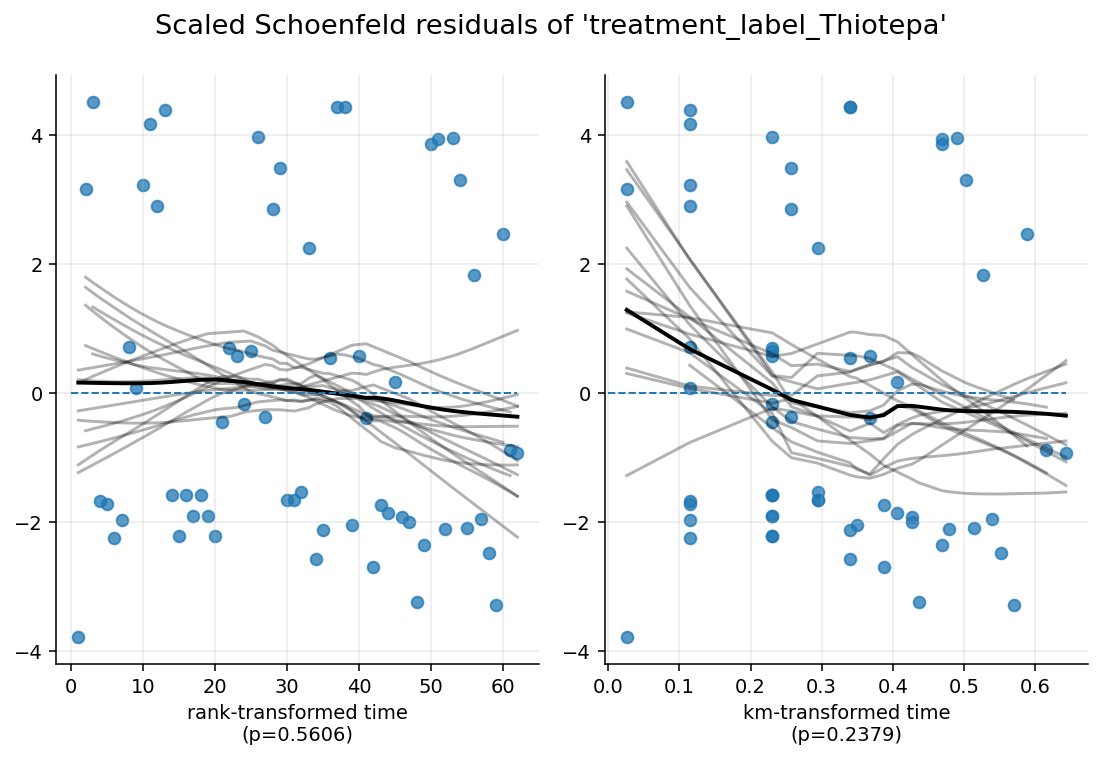

In [23]:
# ============================================================
# CELL 20: Proportional Hazards Assumption Diagnostics
# ============================================================

ph_test = proportional_hazard_test(cph, cox_df, time_transform="rank")
ph_table = ph_test.summary.reset_index().rename(columns={"index": "Variable"})

show_copyable_table(
    ph_table.round(5),
    title="Copyable Table: Proportional Hazards Test",
    filename="proportional_hazards_test.csv"
)

# Lifelines graphical/check output
cph.check_assumptions(cox_df, p_value_threshold=0.05, show_plots=True)


Copyable Table: Penalized Cox Cross-Validation


,Penalizer,Mean CV C-index,SD CV C-index
0,0.001,0.61401,0.04617
1,0.010,0.65061,0.05238
2,0.050,0.60169,0.03037
3,0.100,0.59391,0.06931
4,0.500,0.63421,0.05919
5,1.000,0.63111,0.07623



Copyable Markdown table:
|   Penalizer |   Mean CV C-index |   SD CV C-index |
|------------:|------------------:|----------------:|
|       0.001 |           0.61401 |         0.04617 |
|       0.01  |           0.65061 |         0.05238 |
|       0.05  |           0.60169 |         0.03037 |
|       0.1   |           0.59391 |         0.06931 |
|       0.5   |           0.63421 |         0.05919 |
|       1     |           0.63111 |         0.07623 |

Saved table: outputs_bladder_survival/tables/penalized_cox_cv.csv
Saved: outputs_bladder_survival/figures/penalized_cox_model_selection.png
Saved: outputs_bladder_survival/figures/penalized_cox_model_selection.pdf


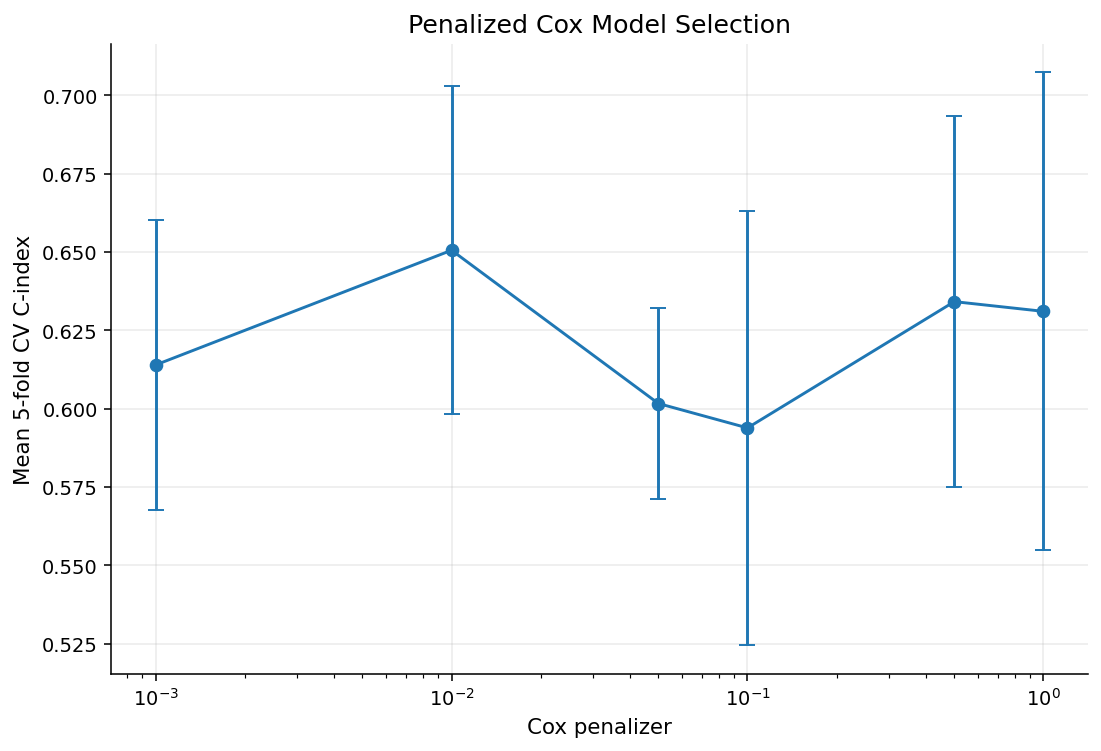

Best penalizer: 0.01


model,lifelines.CoxPHFitter
duration col,'duration'
event col,'event'
penalizer,0.01
l1 ratio,0.0
robust variance,True
baseline estimation,breslow
number of observations,118
number of events observed,62
partial log-likelihood,-256.05
time fit was run,2026-05-14 11:50:34 UTC


In [24]:
# ============================================================
# CELL 21: Penalized Cox Model Selection
# ============================================================

penalizers = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
penalty_rows = []

for pen in penalizers:
    try:
        model = CoxPHFitter(penalizer=pen)
        scores = k_fold_cross_validation(
            model,
            cox_df,
            duration_col="duration",
            event_col="event",
            k=5,
            scoring_method="concordance_index",
        )
        penalty_rows.append({
            "Penalizer": pen,
            "Mean CV C-index": np.mean(scores),
            "SD CV C-index": np.std(scores),
        })
    except Exception as e:
        penalty_rows.append({
            "Penalizer": pen,
            "Mean CV C-index": np.nan,
            "SD CV C-index": np.nan,
        })

penalty_table = pd.DataFrame(penalty_rows)

show_copyable_table(
    penalty_table.round(5),
    title="Copyable Table: Penalized Cox Cross-Validation",
    filename="penalized_cox_cv.csv"
)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.errorbar(
    penalty_table["Penalizer"],
    penalty_table["Mean CV C-index"],
    yerr=penalty_table["SD CV C-index"],
    marker="o",
    capsize=4,
)
ax.set_xscale("log")
ax.set_xlabel("Cox penalizer")
ax.set_ylabel("Mean 5-fold CV C-index")
ax.set_title("Penalized Cox Model Selection")
save_current_figure("penalized_cox_model_selection")
plt.show()

best_pen = penalty_table.sort_values("Mean CV C-index", ascending=False).iloc[0]["Penalizer"]
print("Best penalizer:", best_pen)

cph_pen = CoxPHFitter(penalizer=float(best_pen))
cph_pen.fit(cox_df, duration_col="duration", event_col="event", robust=True)
cph_pen.print_summary()

They are shifted to a very small positive value: 1e-6.
Parametric survival dataset summary
-----------------------------------
N = 118
Events = 62
Censored = 56
Minimum duration = 1e-06
Maximum duration = 60.0
Unique durations = 43


,count,mean,std,min,25%,50%,75%,max
duration,118.0,18.559322,17.271855,0.000001,3.0,11.0,31.25,60.0
event,118.0,0.525424,0.501483,0.000000,0.0,1.0,1.00,1.0


Saved: outputs_bladder_survival/figures/parametric_survival_model_fits.png
Saved: outputs_bladder_survival/figures/parametric_survival_model_fits.pdf


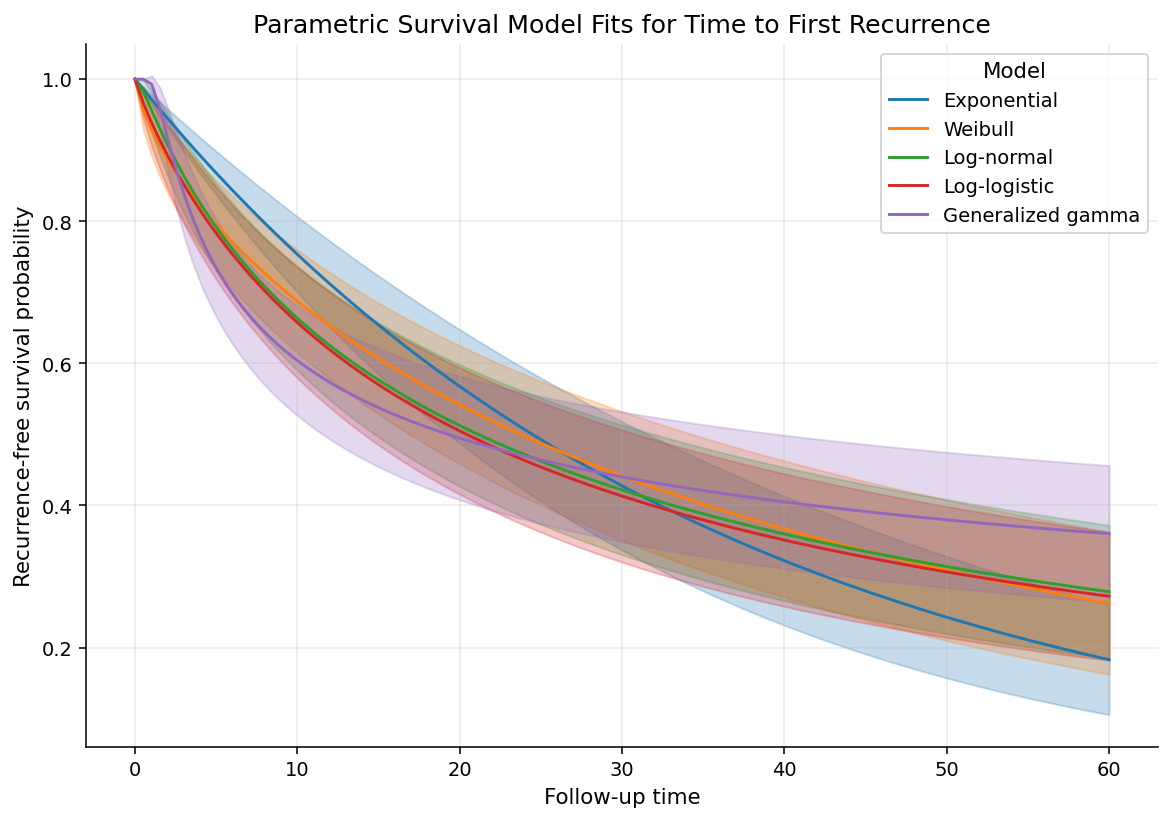


Copyable Table: Parametric Survival Model Comparison


,Model,Fitted,AIC,Log-likelihood,Median recurrence-free time,Error message
0,Generalized gamma,Yes,528.5947,-261.2974,19.2993,
1,Log-normal,Yes,544.7691,-270.3845,21.1520,
2,Log-logistic,Yes,550.6276,-273.3138,20.4330,
3,Weibull,Yes,558.2508,-277.1254,23.7889,
4,Exponential,Yes,568.0008,-283.0004,24.4837,



Copyable Markdown table:
| Model             | Fitted   |     AIC |   Log-likelihood |   Median recurrence-free time | Error message   |
|:------------------|:---------|--------:|-----------------:|------------------------------:|:----------------|
| Generalized gamma | Yes      | 528.595 |         -261.297 |                       19.2993 |                 |
| Log-normal        | Yes      | 544.769 |         -270.385 |                       21.152  |                 |
| Log-logistic      | Yes      | 550.628 |         -273.314 |                       20.433  |                 |
| Weibull           | Yes      | 558.251 |         -277.125 |                       23.7889 |                 |
| Exponential       | Yes      | 568.001 |         -283     |                       24.4837 |                 |

Saved table: outputs_bladder_survival/tables/parametric_model_aic_comparison_corrected.csv

Best parametric model by AIC: Generalized gamma


In [52]:
# ============================================================
# CELL 22: Robust Parametric Survival Model Comparison
# ============================================================

from lifelines import (
    ExponentialFitter,
    WeibullFitter,
    LogNormalFitter,
    LogLogisticFitter,
    GeneralizedGammaFitter
)

# ------------------------------------------------------------
# Step 1: Prepare clean survival data
# ------------------------------------------------------------

param_df = firstrec[["duration", "event"]].copy()

param_df["duration"] = pd.to_numeric(param_df["duration"], errors="coerce")
param_df["event"] = pd.to_numeric(param_df["event"], errors="coerce")

param_df = param_df.dropna(subset=["duration", "event"]).copy()

# Event must be binary integer
param_df["event"] = param_df["event"].astype(int)

# Parametric lifelines models usually require strictly positive durations.
# If zero durations exist, shift them very slightly.
n_nonpositive = (param_df["duration"] <= 0).sum()

if n_nonpositive > 0:
    print(f"Warning: {n_nonpositive} non-positive duration values found.")
    print("They are shifted to a very small positive value: 1e-6.")
    param_df.loc[param_df["duration"] <= 0, "duration"] = 1e-6

T = param_df["duration"].astype(float).values
E = param_df["event"].astype(int).values

print("Parametric survival dataset summary")
print("-----------------------------------")
print("N =", len(T))
print("Events =", int(E.sum()))
print("Censored =", int(len(E) - E.sum()))
print("Minimum duration =", np.min(T))
print("Maximum duration =", np.max(T))
print("Unique durations =", len(np.unique(T)))

display(param_df.describe().T)

# ------------------------------------------------------------
# Step 2: Fit candidate parametric survival models
# ------------------------------------------------------------

parametric_models = {
    "Exponential": ExponentialFitter(),
    "Weibull": WeibullFitter(),
    "Log-normal": LogNormalFitter(),
    "Log-logistic": LogLogisticFitter(),
    "Generalized gamma": GeneralizedGammaFitter(),
}

param_rows = []
fitted_parametric_models = {}

fig, ax = plt.subplots(figsize=(8.5, 6))

for name, model in parametric_models.items():
    try:
        model.fit(
            durations=T,
            event_observed=E,
            label=name
        )

        model.plot_survival_function(ax=ax, ci_show=True)
        fitted_parametric_models[name] = model

        # Some lifelines models expose AIC_ directly.
        aic_value = getattr(model, "AIC_", np.nan)
        log_likelihood = getattr(model, "log_likelihood_", np.nan)
        median_survival = getattr(model, "median_survival_time_", np.nan)

        param_rows.append({
            "Model": name,
            "Fitted": "Yes",
            "AIC": aic_value,
            "Log-likelihood": log_likelihood,
            "Median recurrence-free time": median_survival,
            "Error message": ""
        })

    except Exception as e:
        param_rows.append({
            "Model": name,
            "Fitted": "No",
            "AIC": np.nan,
            "Log-likelihood": np.nan,
            "Median recurrence-free time": np.nan,
            "Error message": str(e)
        })
        print(f"{name} failed: {e}")

ax.set_title("Parametric Survival Model Fits for Time to First Recurrence")
ax.set_xlabel("Follow-up time")
ax.set_ylabel("Recurrence-free survival probability")
ax.legend(title="Model")
save_current_figure("parametric_survival_model_fits")
plt.show()

# ------------------------------------------------------------
# Step 3: Model comparison table
# ------------------------------------------------------------

param_table = pd.DataFrame(param_rows)

# Sort fitted models by AIC, but keep failed models at the bottom
param_table["AIC_sort"] = param_table["AIC"].fillna(np.inf)
param_table = param_table.sort_values("AIC_sort").drop(columns=["AIC_sort"]).reset_index(drop=True)

show_copyable_table(
    param_table.round(4),
    title="Copyable Table: Parametric Survival Model Comparison",
    filename="parametric_model_aic_comparison_corrected.csv"
)

# ------------------------------------------------------------
# Step 4: Identify best parametric model
# ------------------------------------------------------------

valid_param_table = param_table[param_table["Fitted"] == "Yes"].dropna(subset=["AIC"])

if len(valid_param_table) > 0:
    best_param_model_name = valid_param_table.iloc[0]["Model"]
    best_param_model = fitted_parametric_models[best_param_model_name]
    print(f"\nBest parametric model by AIC: {best_param_model_name}")
else:
    best_param_model_name = None
    best_param_model = None
    print("\nNo parametric model could be fitted successfully.")

Saved: outputs_bladder_survival/figures/qq_plot_exponential.png
Saved: outputs_bladder_survival/figures/qq_plot_exponential.pdf


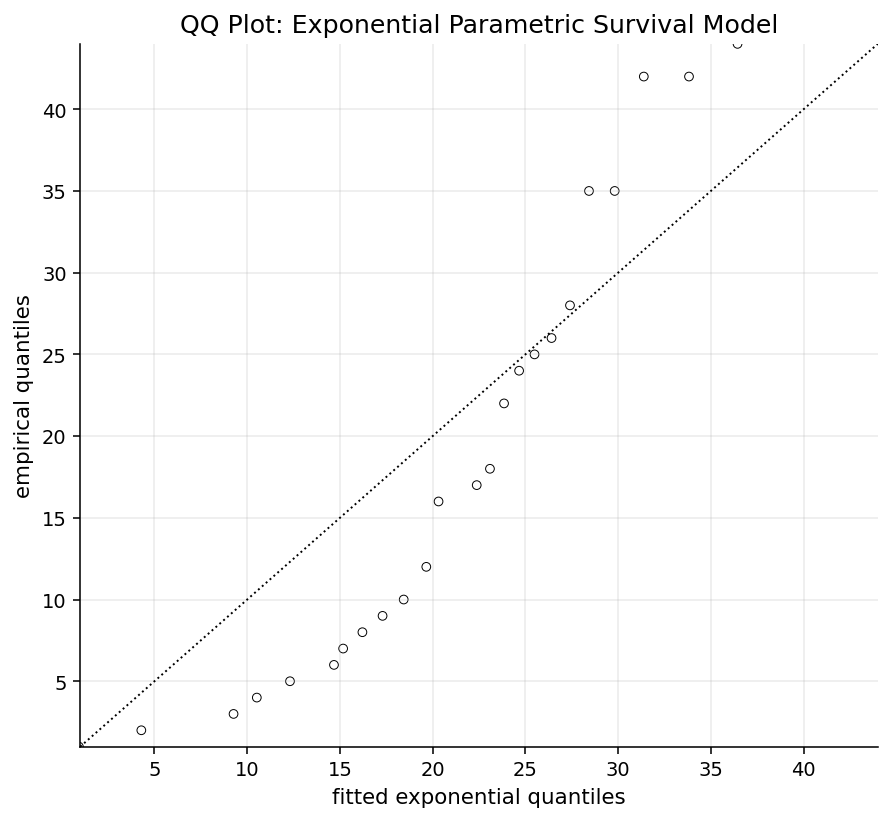

Saved: outputs_bladder_survival/figures/qq_plot_weibull.png
Saved: outputs_bladder_survival/figures/qq_plot_weibull.pdf


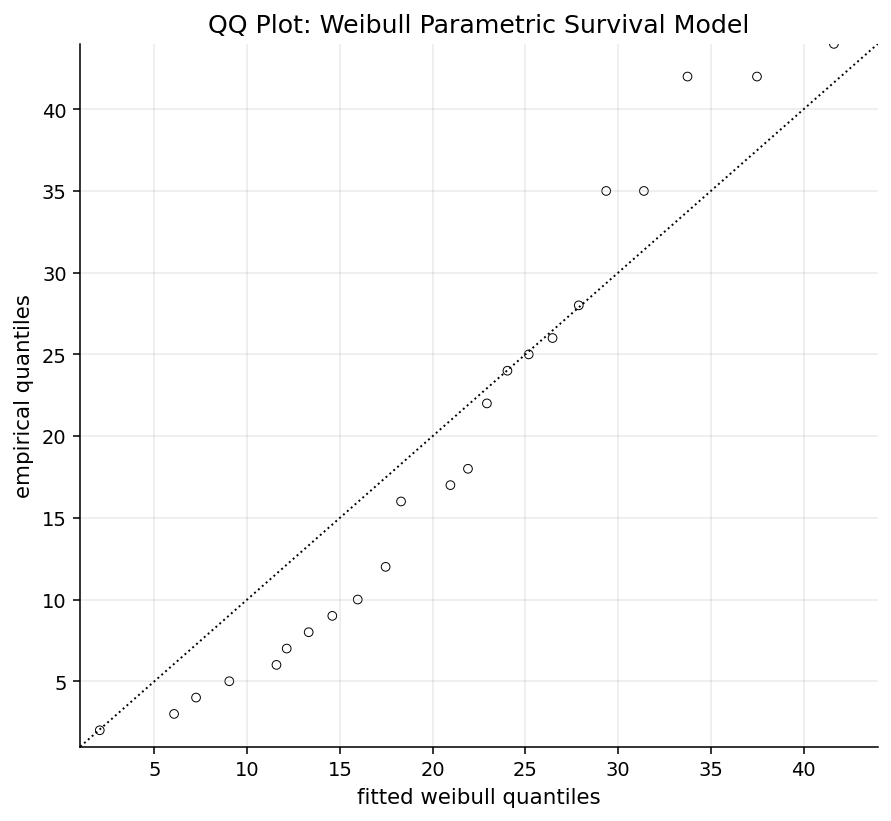

Saved: outputs_bladder_survival/figures/qq_plot_log_normal.png
Saved: outputs_bladder_survival/figures/qq_plot_log_normal.pdf


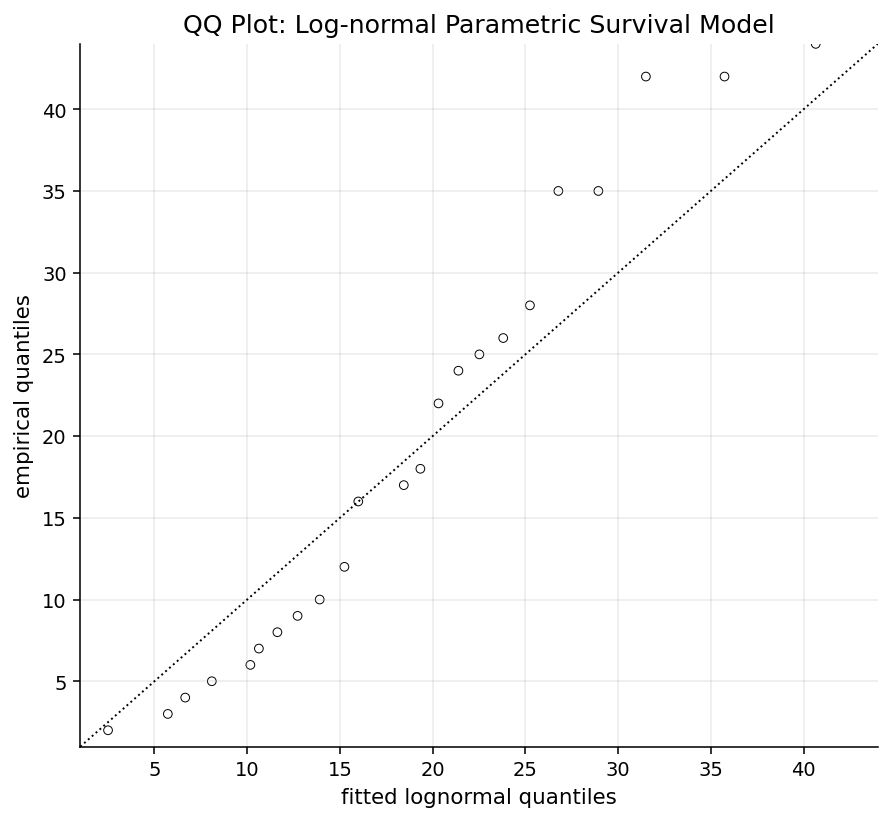

Saved: outputs_bladder_survival/figures/qq_plot_log_logistic.png
Saved: outputs_bladder_survival/figures/qq_plot_log_logistic.pdf


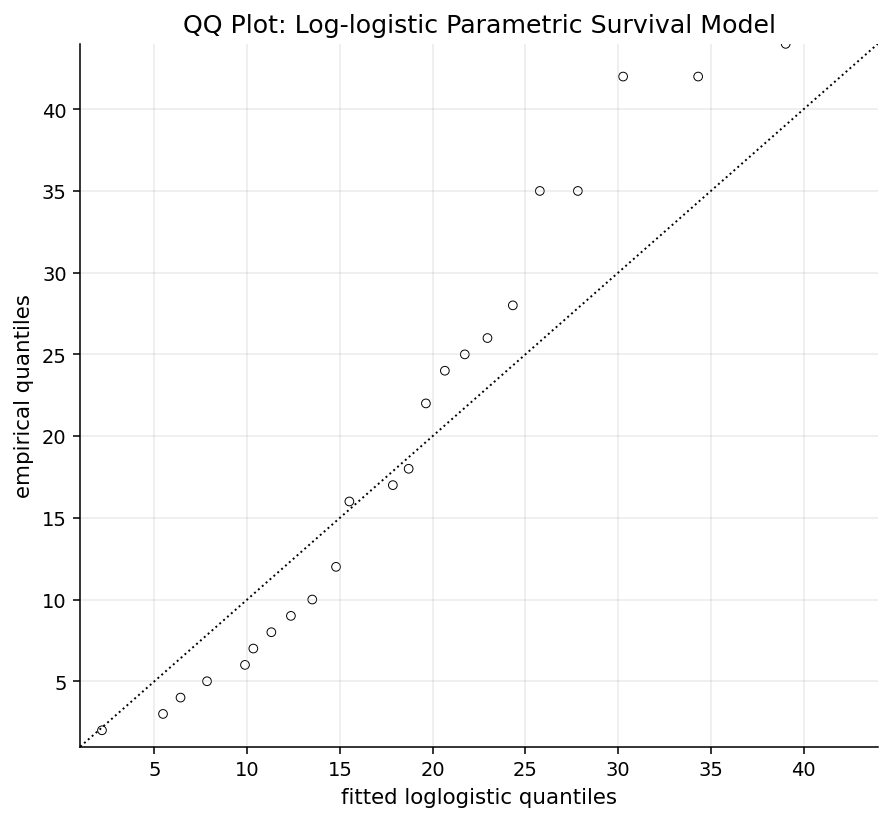

QQ plot failed for Generalized gamma: Distribution not implemented in SciPy


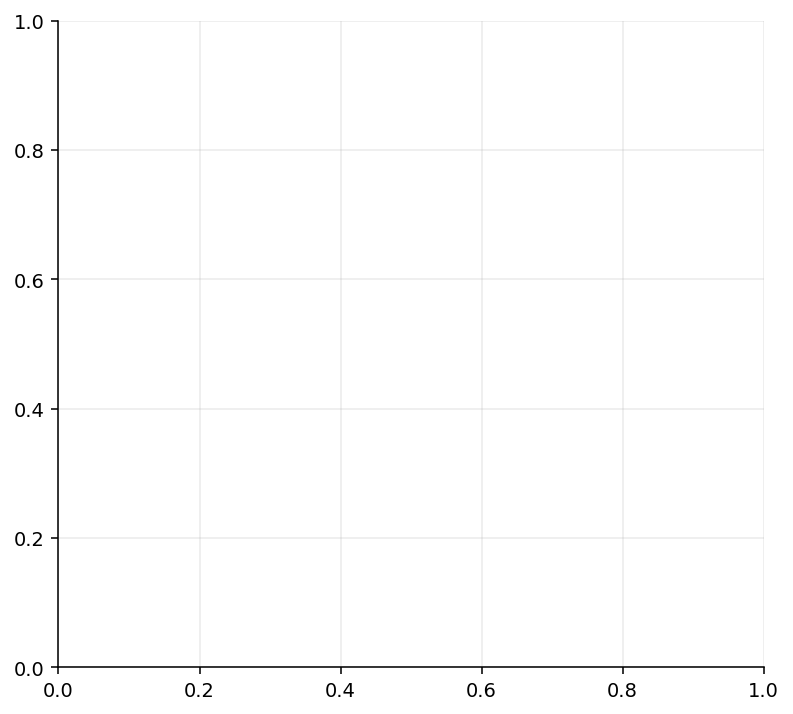

In [53]:
# ============================================================
# CELL 23: QQ Plots for Successfully Fitted Parametric Models
# ============================================================

from lifelines.plotting import qq_plot

if len(fitted_parametric_models) == 0:
    print("No fitted parametric models available for QQ plots.")
else:
    for name, model in fitted_parametric_models.items():
        try:
            fig, ax = plt.subplots(figsize=(6.5, 6))
            qq_plot(model, ax=ax)
            ax.set_title(f"QQ Plot: {name} Parametric Survival Model")
            save_current_figure(f"qq_plot_{name.replace('-', '_').replace(' ', '_').lower()}")
            plt.show()
        except Exception as e:
            print(f"QQ plot failed for {name}: {e}")

In [54]:
#Part B: Recurrent-event modeling using Anderson–Gill style data


# ============================================================
# CELL 24: Prepare Anderson-Gill Recurrent-Event Dataset
# ============================================================
# bladder2.csv is already described as start-stop Anderson-Gill style.
# Event: recurrence.

ag_df = bladder2.copy()

# Make sure required columns exist.
required_cols = ["id", "start", "stop", "event_recurrence", "number", "size", "treatment_label"]
missing = [c for c in required_cols if c not in ag_df.columns]
print("Missing required AG columns:", missing)

ag_model_df = ag_df[required_cols].dropna().copy()

# Remove invalid intervals
ag_model_df = ag_model_df[ag_model_df["stop"] > ag_model_df["start"]].copy()

# Encode treatment
ag_model_df = pd.get_dummies(ag_model_df, columns=["treatment_label"], drop_first=True)

print("AG modeling dataset shape:", ag_model_df.shape)
display(ag_model_df.head())

ag_model_df.to_csv(TABLE_DIR / "anderson_gill_model_dataset.csv", index=False)

Missing required AG columns: []
AG modeling dataset shape: (178, 7)


,id,start,stop,event_recurrence,number,size,treatment_label_Thiotepa
0,1,0,1,1,1,3,False
1,2,0,4,1,2,1,False
2,3,0,7,1,1,1,False
3,4,0,10,1,5,1,False
4,5,0,6,1,4,1,False


In [55]:
# ============================================================
# CELL 25: Cox Time-Varying Anderson-Gill Model
# Corrected: robust=True removed because lifelines does not
# currently support robust variance in CoxTimeVaryingFitter.
# ============================================================

from lifelines import CoxTimeVaryingFitter

# ------------------------------------------------------------
# Step 1: Re-check Anderson-Gill data
# ------------------------------------------------------------

ag_fit_df = ag_model_df.copy()

# Ensure numeric columns are numeric
for col in ["id", "start", "stop", "event_recurrence", "number", "size"]:
    if col in ag_fit_df.columns:
        ag_fit_df[col] = pd.to_numeric(ag_fit_df[col], errors="coerce")

# Drop missing values
ag_fit_df = ag_fit_df.dropna().copy()

# Keep only valid time intervals
ag_fit_df = ag_fit_df[ag_fit_df["stop"] > ag_fit_df["start"]].copy()

# Event column must be integer/binary
ag_fit_df["event_recurrence"] = ag_fit_df["event_recurrence"].astype(int)

# Patient ID should remain identifier
ag_fit_df["id"] = ag_fit_df["id"].astype(int)

print("Anderson-Gill dataset used for Cox time-varying model")
print("Rows:", ag_fit_df.shape[0])
print("Patients:", ag_fit_df["id"].nunique())
print("Events:", ag_fit_df["event_recurrence"].sum())
print("Censored intervals:", ag_fit_df.shape[0] - ag_fit_df["event_recurrence"].sum())

display(ag_fit_df.head())

# ------------------------------------------------------------
# Step 2: Fit Cox time-varying Anderson-Gill model
# ------------------------------------------------------------

ctv = CoxTimeVaryingFitter(penalizer=0.01)

ctv.fit(
    ag_fit_df,
    id_col="id",
    start_col="start",
    stop_col="stop",
    event_col="event_recurrence",
    show_progress=True
)

ctv.print_summary()

# ------------------------------------------------------------
# Step 3: Export model summary table
# ------------------------------------------------------------

ctv_summary = ctv.summary.reset_index().rename(columns={"covariate": "Variable"})

show_copyable_table(
    ctv_summary.round(5),
    title="Copyable Table: Anderson-Gill Cox Time-Varying Model",
    filename="anderson_gill_cox_time_varying_summary_corrected.csv"
)

Anderson-Gill dataset used for Cox time-varying model
Rows: 178
Patients: 85
Events: 178
Censored intervals: 0


,id,start,stop,event_recurrence,number,size,treatment_label_Thiotepa
0,1,0,1,1,1,3,False
1,2,0,4,1,2,1,False
2,3,0,7,1,1,1,False
3,4,0,10,1,5,1,False
4,5,0,6,1,4,1,False


Iteration 1: norm_delta = 2.94e-01, step_size = 0.9500, log_lik = -680.85646, newton_decrement = 6.75e+00, seconds_since_start = 0.0
Iteration 2: norm_delta = 2.61e-02, step_size = 0.9500, log_lik = -674.62324, newton_decrement = 7.04e-02, seconds_since_start = 0.0
Iteration 3: norm_delta = 1.84e-03, step_size = 0.9500, log_lik = -674.55221, newton_decrement = 3.33e-04, seconds_since_start = 0.0
Iteration 4: norm_delta = 9.93e-05, step_size = 1.0000, log_lik = -674.55188, newton_decrement = 8.79e-07, seconds_since_start = 0.1
Iteration 5: norm_delta = 7.43e-09, step_size = 1.0000, log_lik = -674.55188, newton_decrement = 4.88e-15, seconds_since_start = 0.1
Convergence completed after 5 iterations.


<lifelines.CoxTimeVaryingFitter: fitted with 178 periods, 85 subjects, 178 events>
         event col = 'event_recurrence'
         penalizer = 0.01
number of subjects = 85
 number of periods = 178
  number of events = 178
partial log-likelihood = -674.55
  time fit was run = 2026-05-14 11:59:24 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                 
number                    0.12      1.13      0.04            0.04            0.20                1.04                1.23
size                     -0.05      0.95      0.05           -0.15            0.05                0.86                1.05
treatment_label_Thiotepa -0.30      0.74      0.15           -0.60           -0.00                0.55                1.00

                          cmp to     z      p  -log2(p)
covariate                                              
number                      0.00  2.94 <0.005      8.23
size                        0.00 -0.97   0.33      1.58
treatment_label_Thiotepa    0.00 -1.96   0.05      4.33
---
Partial AIC = 1355.10
log-likelihood ratio test = 12.61 on 3 df
-log2(p) of ll-ratio test = 7.49


Copyable Table: Anderson-Gill Cox Time-Varying Model


,Variable,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
0,number,0.12269,1.13054,0.04179,0.04079,0.20460,1.04163,1.22703,0.0,2.93599,0.00332,8.23251
1,size,-0.05059,0.95066,0.05242,-0.15333,0.05215,0.85784,1.05353,0.0,-0.96518,0.33446,1.58011
2,treatment_label_Thiotepa,-0.30257,0.73892,0.15421,-0.60482,-0.00032,0.54617,0.99968,0.0,-1.96205,0.04976,4.32898



Copyable Markdown table:
| Variable                 |     coef |   exp(coef) |   se(coef) |   coef lower 95% |   coef upper 95% |   exp(coef) lower 95% |   exp(coef) upper 95% |   cmp to |        z |       p |   -log2(p) |
|:-------------------------|---------:|------------:|-----------:|-----------------:|-----------------:|----------------------:|----------------------:|---------:|---------:|--------:|-----------:|
| number                   |  0.12269 |     1.13054 |    0.04179 |          0.04079 |          0.2046  |               1.04163 |               1.22703 |        0 |  2.93599 | 0.00332 |    8.23251 |
| size                     | -0.05059 |     0.95066 |    0.05242 |         -0.15333 |          0.05215 |               0.85784 |               1.05353 |        0 | -0.96518 | 0.33446 |    1.58011 |
| treatment_label_Thiotepa | -0.30257 |     0.73892 |    0.15421 |         -0.60482 |         -0.00032 |               0.54617 |               0.99968 |        0 | -1.96205 | 0.04976

Saved: outputs_bladder_survival/figures/anderson_gill_hazard_ratio_forest_plot.png
Saved: outputs_bladder_survival/figures/anderson_gill_hazard_ratio_forest_plot.pdf


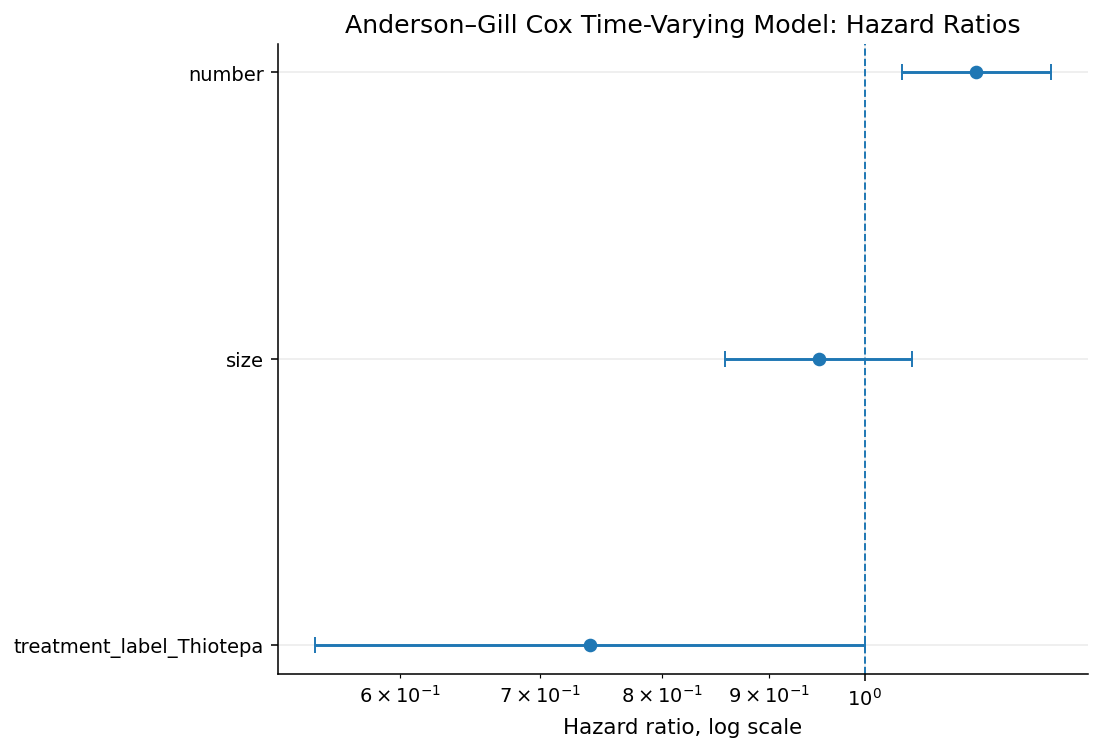


Copyable Table: Anderson-Gill Hazard Ratios with 95% CI


,Variable,HR,HR_lower_95,HR_upper_95,p
0,number,1.13054,1.04163,1.22703,0.00332
1,size,0.95066,0.85784,1.05353,0.33446
2,treatment_label_Thiotepa,0.73892,0.54617,0.99968,0.04976



Copyable Markdown table:
| Variable                 |      HR |   HR_lower_95 |   HR_upper_95 |       p |
|:-------------------------|--------:|--------------:|--------------:|--------:|
| number                   | 1.13054 |       1.04163 |       1.22703 | 0.00332 |
| size                     | 0.95066 |       0.85784 |       1.05353 | 0.33446 |
| treatment_label_Thiotepa | 0.73892 |       0.54617 |       0.99968 | 0.04976 |

Saved table: outputs_bladder_survival/tables/anderson_gill_hazard_ratios_corrected.csv


In [56]:
# ============================================================
# CELL 25B: Anderson-Gill Hazard-Ratio Forest Plot
# ============================================================

ctv_hr = ctv_summary.copy()

ctv_hr["HR"] = np.exp(ctv_hr["coef"])
ctv_hr["HR_lower_95"] = np.exp(ctv_hr["coef lower 95%"])
ctv_hr["HR_upper_95"] = np.exp(ctv_hr["coef upper 95%"])

plot_df = ctv_hr.sort_values("HR").copy()

fig, ax = plt.subplots(figsize=(8, 5.5))

y_pos = np.arange(len(plot_df))

ax.errorbar(
    plot_df["HR"],
    y_pos,
    xerr=[
        plot_df["HR"] - plot_df["HR_lower_95"],
        plot_df["HR_upper_95"] - plot_df["HR"]
    ],
    fmt="o",
    capsize=4
)

ax.axvline(1.0, linestyle="--", linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["Variable"])
ax.set_xscale("log")
ax.set_xlabel("Hazard ratio, log scale")
ax.set_title("Anderson–Gill Cox Time-Varying Model: Hazard Ratios")

save_current_figure("anderson_gill_hazard_ratio_forest_plot")
plt.show()

show_copyable_table(
    ctv_hr[["Variable", "HR", "HR_lower_95", "HR_upper_95", "p"]].round(5),
    title="Copyable Table: Anderson-Gill Hazard Ratios with 95% CI",
    filename="anderson_gill_hazard_ratios_corrected.csv"
)

In [57]:
# ============================================================
# CELL 25C: Manuscript-Ready Methodological Note
# ============================================================

ag_note = """
Anderson-Gill recurrent-event modeling was performed using a Cox time-varying model with start-stop intervals.
The model treated each recurrence interval as an observation and used patient ID to define repeated intervals.
In the current lifelines implementation, robust sandwich variance estimation is not available for CoxTimeVaryingFitter;
therefore, standard model-based confidence intervals are reported for the Anderson-Gill model.
For clinical inference, these estimates should be interpreted cautiously because recurrent intervals within the same patient are correlated.
"""

print(ag_note)

with open(OUTPUT_DIR / "anderson_gill_methodological_note.txt", "w") as f:
    f.write(ag_note)


Anderson-Gill recurrent-event modeling was performed using a Cox time-varying model with start-stop intervals.
The model treated each recurrence interval as an observation and used patient ID to define repeated intervals.
In the current lifelines implementation, robust sandwich variance estimation is not available for CoxTimeVaryingFitter;
therefore, standard model-based confidence intervals are reported for the Anderson-Gill model.
For clinical inference, these estimates should be interpreted cautiously because recurrent intervals within the same patient are correlated.



Saved: outputs_bladder_survival/figures/recurrent_event_burden_by_treatment.png
Saved: outputs_bladder_survival/figures/recurrent_event_burden_by_treatment.pdf


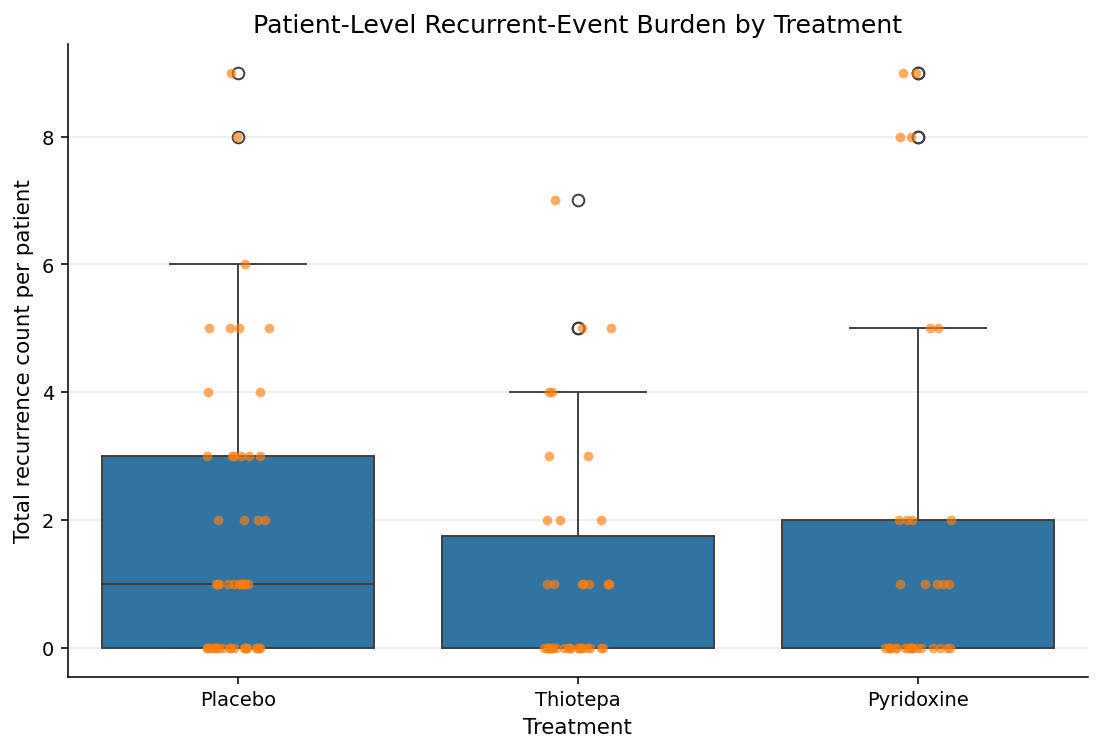


Copyable Table: Recurrent-Event Burden by Treatment


,Treatment,count,mean,std,median,min,max
0,Placebo,48,1.812,2.238,1.0,0,9
1,Pyridoxine,32,1.781,2.893,0.0,0,9
2,Thiotepa,38,1.184,1.768,0.0,0,7



Copyable Markdown table:
| Treatment   |   count |   mean |   std |   median |   min |   max |
|:------------|--------:|-------:|------:|---------:|------:|------:|
| Placebo     |      48 |  1.812 | 2.238 |        1 |     0 |     9 |
| Pyridoxine  |      32 |  1.781 | 2.893 |        0 |     0 |     9 |
| Thiotepa    |      38 |  1.184 | 1.768 |        0 |     0 |     7 |

Saved table: outputs_bladder_survival/tables/recurrent_event_burden_by_treatment.csv


In [32]:
# ============================================================
# CELL 26: Recurrent-Event Burden by Treatment
# ============================================================

burden_df = (
    bladder1
    .groupby(["id", "treatment_label"])
    .agg(
        total_recurrences=("event_recurrence", "sum"),
        max_followup=("stop", "max"),
        baseline_number=("number", "first"),
        baseline_size=("size", "first"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.boxplot(
    data=burden_df,
    x="treatment_label",
    y="total_recurrences",
    order=treatment_order(burden_df["treatment_label"]),
    ax=ax,
)
sns.stripplot(
    data=burden_df,
    x="treatment_label",
    y="total_recurrences",
    order=treatment_order(burden_df["treatment_label"]),
    ax=ax,
    alpha=0.65,
)
ax.set_title("Patient-Level Recurrent-Event Burden by Treatment")
ax.set_xlabel("Treatment")
ax.set_ylabel("Total recurrence count per patient")
save_current_figure("recurrent_event_burden_by_treatment")
plt.show()

burden_summary = (
    burden_df
    .groupby("treatment_label")["total_recurrences"]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .reset_index()
    .rename(columns={"treatment_label": "Treatment"})
)

show_copyable_table(
    burden_summary.round(3),
    title="Copyable Table: Recurrent-Event Burden by Treatment",
    filename="recurrent_event_burden_by_treatment.csv"
)

In [34]:
# ============================================================
# CELL 27: Poisson and Negative Binomial Models for Recurrence Burden
# ============================================================

import statsmodels.api as sm
import statsmodels.formula.api as smf

count_df = burden_df.copy()
count_df["log_followup"] = np.log(count_df["max_followup"].clip(lower=1e-6))

# Poisson model with exposure offset
poisson_model = smf.glm(
    formula="total_recurrences ~ C(treatment_label) + baseline_number + baseline_size",
    data=count_df,
    family=sm.families.Poisson(),
    offset=count_df["log_followup"],
).fit()

# Negative binomial model
nb_model = smf.glm(
    formula="total_recurrences ~ C(treatment_label) + baseline_number + baseline_size",
    data=count_df,
    family=sm.families.NegativeBinomial(),
    offset=count_df["log_followup"],
).fit()

print("Poisson Model")
print(poisson_model.summary())

print("\nNegative Binomial Model")
print(nb_model.summary())

count_model_table = pd.DataFrame({
    "Model": ["Poisson", "Negative binomial"],
    "AIC": [poisson_model.aic, nb_model.aic],
    "BIC": [poisson_model.bic, nb_model.bic],
    "Log-likelihood": [poisson_model.llf, nb_model.llf],
})

show_copyable_table(
    count_model_table.round(4),
    title="Copyable Table: Recurrence Burden Count Model Comparison",
    filename="recurrence_burden_count_model_comparison.csv"
)

Poisson Model
                 Generalized Linear Model Regression Results                  
Dep. Variable:      total_recurrences   No. Observations:                  118
Model:                            GLM   Df Residuals:                      113
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -220.21
Date:                Thu, 14 May 2026   Deviance:                       269.38
Time:                        11:52:18   Pearson chi2:                     269.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.2293
Covariance Type:            nonrobust                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


,Model,AIC,BIC,Log-likelihood
0,Poisson,450.4131,-269.7079,-220.2065
1,Negative binomial,386.6125,-417.6256,-188.3063



Copyable Markdown table:
| Model             |     AIC |      BIC |   Log-likelihood |
|:------------------|--------:|---------:|-----------------:|
| Poisson           | 450.413 | -269.708 |         -220.207 |
| Negative binomial | 386.613 | -417.626 |         -188.306 |

Saved table: outputs_bladder_survival/tables/recurrence_burden_count_model_comparison.csv


In [35]:
# Part C: Machine-learning survival models

# ============================================================
# CELL 28: Prepare Data for scikit-survival
# ============================================================

ml_df = firstrec[["duration", "event", "treatment_label", "number", "size"]].dropna().copy()

X = ml_df.drop(columns=["duration", "event"])
y = Surv.from_arrays(
    event=ml_df["event"].astype(bool).values,
    time=ml_df["duration"].astype(float).values,
)

X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X,
    y,
    np.arange(len(X)),
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=ml_df["event"],
)

categorical_features = ["treatment_label"]
numeric_features = ["number", "size"]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features),
    ]
)

print("Training sample:", X_train.shape)
print("Test sample:", X_test.shape)

Training sample: (82, 3)
Test sample: (36, 3)


In [36]:
# ============================================================
# CELL 29: Random Survival Forest Training
# ============================================================

rsf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomSurvivalForest(
        n_estimators=500,
        min_samples_split=8,
        min_samples_leaf=5,
        max_features="sqrt",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ))
])

rsf.fit(X_train, y_train)

rsf_train_score = rsf.score(X_train, y_train)
rsf_test_score = rsf.score(X_test, y_test)

rsf_results = pd.DataFrame([{
    "Model": "Random Survival Forest",
    "Train C-index": rsf_train_score,
    "Test C-index": rsf_test_score,
}])

show_copyable_table(
    rsf_results.round(4),
    title="Copyable Table: Random Survival Forest C-index",
    filename="rsf_cindex.csv"
)


Copyable Table: Random Survival Forest C-index


,Model,Train C-index,Test C-index
0,Random Survival Forest,0.6749,0.7148



Copyable Markdown table:
| Model                  |   Train C-index |   Test C-index |
|:-----------------------|----------------:|---------------:|
| Random Survival Forest |          0.6749 |         0.7148 |

Saved table: outputs_bladder_survival/tables/rsf_cindex.csv


In [37]:
# ============================================================
# CELL 30: Penalized Coxnet Survival Model
# ============================================================

coxnet = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", CoxnetSurvivalAnalysis(
        l1_ratio=0.5,
        alpha_min_ratio=0.01,
        n_alphas=50,
        max_iter=100000,
    ))
])

coxnet.fit(X_train, y_train)

# Use first fitted alpha by default for risk prediction.
coxnet_risk_train = coxnet.predict(X_train)
coxnet_risk_test = coxnet.predict(X_test)

coxnet_train_c = concordance_index_censored(
    y_train["event"], y_train["time"], coxnet_risk_train
)[0]

coxnet_test_c = concordance_index_censored(
    y_test["event"], y_test["time"], coxnet_risk_test
)[0]

coxnet_results = pd.DataFrame([{
    "Model": "Elastic-net Coxnet",
    "Train C-index": coxnet_train_c,
    "Test C-index": coxnet_test_c,
}])

show_copyable_table(
    coxnet_results.round(4),
    title="Copyable Table: Elastic-net Coxnet C-index",
    filename="coxnet_cindex.csv"
)


Copyable Table: Elastic-net Coxnet C-index


,Model,Train C-index,Test C-index
0,Elastic-net Coxnet,0.6245,0.6901



Copyable Markdown table:
| Model              |   Train C-index |   Test C-index |
|:-------------------|----------------:|---------------:|
| Elastic-net Coxnet |          0.6245 |         0.6901 |

Saved table: outputs_bladder_survival/tables/coxnet_cindex.csv


Evaluation times: [ 1.000001  15.0000005 29.        42.9999995 56.999999 ]

Copyable Table: Time-Dependent AUC


,Time,RSF time-dependent AUC
0,1.0,0.9143
1,15.0,0.7138
2,29.0,0.6619
3,43.0,0.4277
4,57.0,0.3812



Copyable Markdown table:
|   Time |   RSF time-dependent AUC |
|-------:|-------------------------:|
|      1 |                   0.9143 |
|     15 |                   0.7138 |
|     29 |                   0.6619 |
|     43 |                   0.4277 |
|     57 |                   0.3812 |

Saved table: outputs_bladder_survival/tables/rsf_time_dependent_auc_corrected.csv

Copyable Table: Integrated Brier Score and Mean AUC


,Model,Risk time,Integrated Brier Score,Mean time-dependent AUC
0,Random Survival Forest,29.0,0.3078,0.6761



Copyable Markdown table:
| Model                  |   Risk time |   Integrated Brier Score |   Mean time-dependent AUC |
|:-----------------------|------------:|-------------------------:|--------------------------:|
| Random Survival Forest |          29 |                   0.3078 |                    0.6761 |

Saved table: outputs_bladder_survival/tables/rsf_integrated_brier_score_corrected.csv
Saved: outputs_bladder_survival/figures/rsf_time_dependent_auc_corrected.png
Saved: outputs_bladder_survival/figures/rsf_time_dependent_auc_corrected.pdf


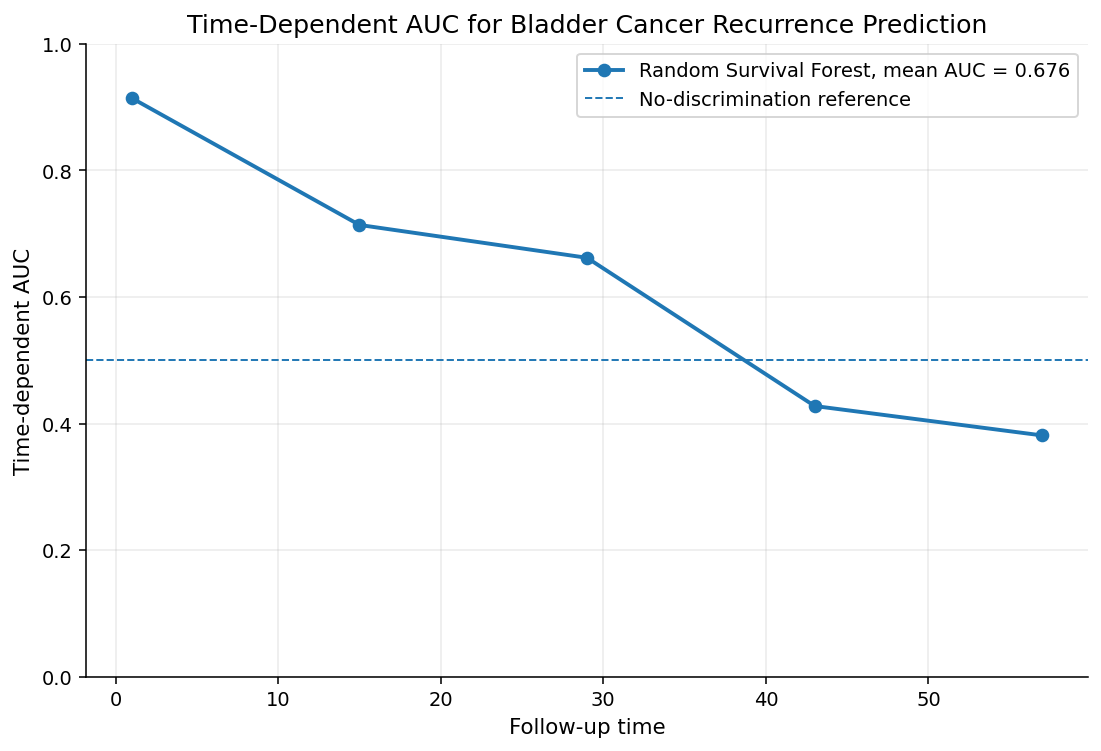

In [58]:
# ============================================================
# CELL 31: Time-Dependent AUC and Integrated Brier Score
# Corrected version
# ============================================================

# ------------------------------------------------------------
# Step 1: Choose valid evaluation times
# ------------------------------------------------------------

train_times = y_train["time"]
test_times = y_test["time"]

# Evaluation times must lie inside the observed follow-up range
# of the test data and should not touch the exact maximum.
min_time = max(np.min(test_times), np.min(train_times)) + 1e-6
max_time = min(np.max(test_times), np.max(train_times)) - 1e-6

# Avoid too many time points for a small dataset
eval_times = np.linspace(min_time, max_time, 5)

print("Evaluation times:", eval_times)

# ------------------------------------------------------------
# Step 2: Extract fitted RSF model and transformed data
# ------------------------------------------------------------

rsf_model = rsf.named_steps["model"]

X_test_trans = rsf.named_steps["preprocess"].transform(X_test)
X_train_trans = rsf.named_steps["preprocess"].transform(X_train)

rsf_surv_test = rsf_model.predict_survival_function(X_test_trans)
rsf_surv_train = rsf_model.predict_survival_function(X_train_trans)

# ------------------------------------------------------------
# Step 3: Define survival-at-time helper
# ------------------------------------------------------------

def survival_at_time(surv_funcs, t):
    return np.array([float(fn(t)) for fn in surv_funcs])

# Clinically representative risk time
risk_time = float(np.median(eval_times))

# Risk score at fixed time:
# higher value = higher predicted recurrence risk
rsf_risk_test = 1.0 - survival_at_time(rsf_surv_test, risk_time)
rsf_risk_train = 1.0 - survival_at_time(rsf_surv_train, risk_time)

# ------------------------------------------------------------
# Step 4: Time-dependent AUC
# ------------------------------------------------------------
# Important:
# cumulative_dynamic_auc returns:
#   auc_values, mean_auc
# not:
#   auc_times, auc_values

rsf_auc_values, rsf_mean_auc = cumulative_dynamic_auc(
    y_train,
    y_test,
    rsf_risk_test,
    eval_times,
)

auc_table = pd.DataFrame({
    "Time": eval_times,
    "RSF time-dependent AUC": rsf_auc_values,
})

# ------------------------------------------------------------
# Step 5: Integrated Brier Score
# ------------------------------------------------------------

rsf_surv_matrix_test = np.row_stack([
    [float(fn(t)) for t in eval_times] for fn in rsf_surv_test
])

rsf_ibs = integrated_brier_score(
    y_train,
    y_test,
    rsf_surv_matrix_test,
    eval_times,
)

metric_table = pd.DataFrame([{
    "Model": "Random Survival Forest",
    "Risk time": risk_time,
    "Integrated Brier Score": rsf_ibs,
    "Mean time-dependent AUC": rsf_mean_auc,
}])

# ------------------------------------------------------------
# Step 6: Display copyable tables
# ------------------------------------------------------------

show_copyable_table(
    auc_table.round(4),
    title="Copyable Table: Time-Dependent AUC",
    filename="rsf_time_dependent_auc_corrected.csv"
)

show_copyable_table(
    metric_table.round(4),
    title="Copyable Table: Integrated Brier Score and Mean AUC",
    filename="rsf_integrated_brier_score_corrected.csv"
)

# ------------------------------------------------------------
# Step 7: Publication-grade plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.plot(
    auc_table["Time"],
    auc_table["RSF time-dependent AUC"],
    marker="o",
    linewidth=2,
    label=f"Random Survival Forest, mean AUC = {rsf_mean_auc:.3f}"
)

ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1,
    label="No-discrimination reference"
)

ax.set_xlabel("Follow-up time")
ax.set_ylabel("Time-dependent AUC")
ax.set_ylim(0.0, 1.0)
ax.set_title("Time-Dependent AUC for Bladder Cancer Recurrence Prediction")
ax.legend(loc="best")

save_current_figure("rsf_time_dependent_auc_corrected")
plt.show()


Copyable Table: Time-Dependent Brier Score


,Time,RSF Brier score
0,1.0,0.0291
1,15.0,0.2153
2,29.0,0.1805
3,43.0,0.2482
4,57.0,1.1453



Copyable Markdown table:
|   Time |   RSF Brier score |
|-------:|------------------:|
|      1 |            0.0291 |
|     15 |            0.2153 |
|     29 |            0.1805 |
|     43 |            0.2482 |
|     57 |            1.1453 |

Saved table: outputs_bladder_survival/tables/rsf_time_dependent_brier_score.csv
Saved: outputs_bladder_survival/figures/rsf_time_dependent_brier_score.png
Saved: outputs_bladder_survival/figures/rsf_time_dependent_brier_score.pdf


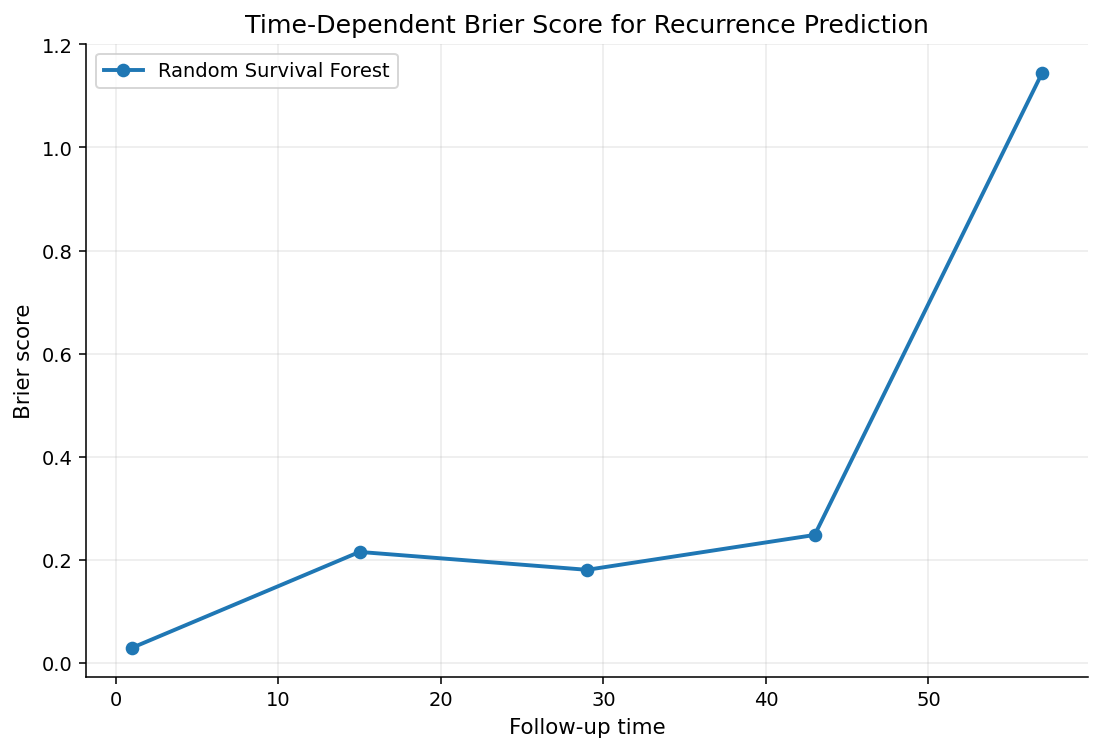

In [59]:
# ============================================================
# CELL 31B: Time-Dependent Brier Score Curve
# ============================================================

times_brier, brier_values = brier_score(
    y_train,
    y_test,
    rsf_surv_matrix_test,
    eval_times,
)

brier_table = pd.DataFrame({
    "Time": times_brier,
    "RSF Brier score": brier_values,
})

show_copyable_table(
    brier_table.round(4),
    title="Copyable Table: Time-Dependent Brier Score",
    filename="rsf_time_dependent_brier_score.csv"
)

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.plot(
    brier_table["Time"],
    brier_table["RSF Brier score"],
    marker="o",
    linewidth=2,
    label="Random Survival Forest"
)

ax.set_xlabel("Follow-up time")
ax.set_ylabel("Brier score")
ax.set_title("Time-Dependent Brier Score for Recurrence Prediction")
ax.legend(loc="best")

save_current_figure("rsf_time_dependent_brier_score")
plt.show()


Copyable Table: RSF Calibration at Time 29.00


,Risk group,N,Mean predicted risk,Observed KM risk,Absolute calibration error
0,0,11,0.3873,0.2500,0.1373
1,1,7,0.5356,0.6190,0.0834
2,2,9,0.6044,0.5833,0.0211
3,3,9,0.6705,0.7778,0.1073



Copyable Markdown table:
|   Risk group |   N |   Mean predicted risk |   Observed KM risk |   Absolute calibration error |
|-------------:|----:|----------------------:|-------------------:|-----------------------------:|
|            0 |  11 |                0.3873 |             0.25   |                       0.1373 |
|            1 |   7 |                0.5356 |             0.619  |                       0.0834 |
|            2 |   9 |                0.6044 |             0.5833 |                       0.0211 |
|            3 |   9 |                0.6705 |             0.7778 |                       0.1073 |

Saved table: outputs_bladder_survival/tables/rsf_calibration_table.csv
Saved: outputs_bladder_survival/figures/rsf_calibration_plot.png
Saved: outputs_bladder_survival/figures/rsf_calibration_plot.pdf


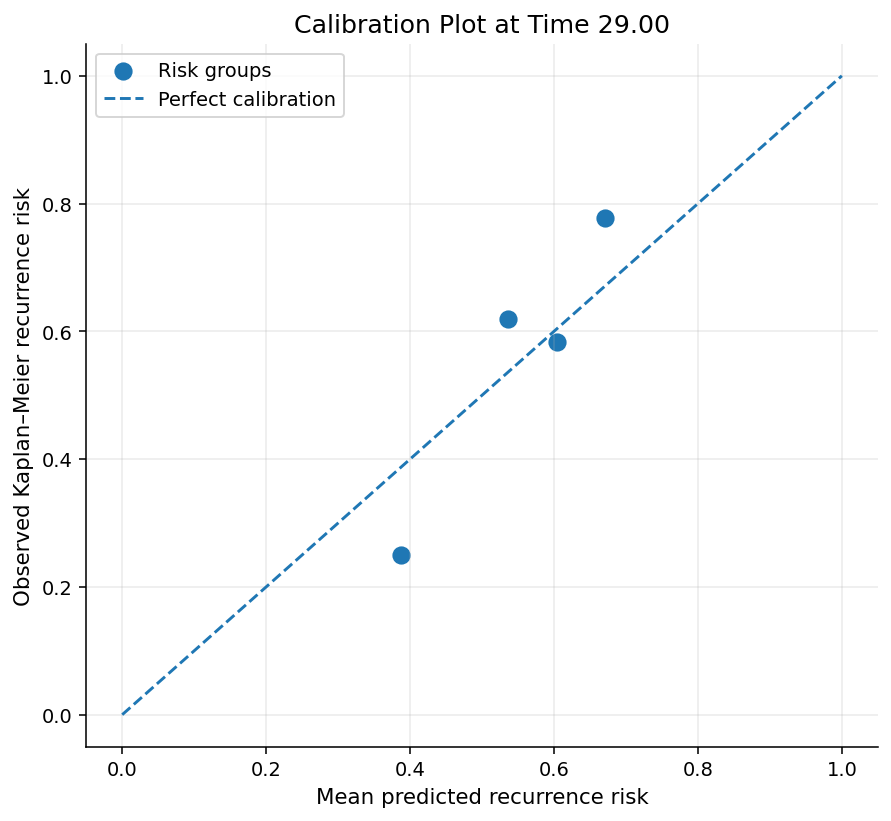

In [39]:
# ============================================================
# CELL 32: Survival Calibration at Selected Time
# ============================================================

calibration_time = risk_time

test_df_cal = X_test.copy()
test_df_cal["observed_time"] = y_test["time"]
test_df_cal["observed_event"] = y_test["event"].astype(int)
test_df_cal["predicted_risk"] = rsf_risk_test

# Group into risk quantiles
test_df_cal["risk_group"] = pd.qcut(
    test_df_cal["predicted_risk"],
    q=min(4, test_df_cal["predicted_risk"].nunique()),
    labels=False,
    duplicates="drop"
)

cal_rows = []

for group, g in test_df_cal.groupby("risk_group"):
    kmf = KaplanMeierFitter()
    kmf.fit(g["observed_time"], g["observed_event"])
    observed_risk = 1 - float(kmf.survival_function_at_times([calibration_time]).values[0])
    predicted_risk = g["predicted_risk"].mean()

    cal_rows.append({
        "Risk group": int(group),
        "N": len(g),
        "Mean predicted risk": predicted_risk,
        "Observed KM risk": observed_risk,
        "Absolute calibration error": abs(predicted_risk - observed_risk),
    })

calibration_table = pd.DataFrame(cal_rows)

show_copyable_table(
    calibration_table.round(4),
    title=f"Copyable Table: RSF Calibration at Time {calibration_time:.2f}",
    filename="rsf_calibration_table.csv"
)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(
    calibration_table["Mean predicted risk"],
    calibration_table["Observed KM risk"],
    s=70,
    label="Risk groups"
)
ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
ax.set_xlabel("Mean predicted recurrence risk")
ax.set_ylabel("Observed Kaplan–Meier recurrence risk")
ax.set_title(f"Calibration Plot at Time {calibration_time:.2f}")
ax.legend()
save_current_figure("rsf_calibration_plot")
plt.show()


Copyable Table: Decision-Curve Analysis


,Threshold probability,Model net benefit,Treat-all net benefit,Treat-none net benefit
0,0.050,0.47368,0.47368,0.0
1,0.075,0.45946,0.45946,0.0
2,0.100,0.44444,0.44444,0.0
3,0.125,0.42857,0.42857,0.0
4,0.150,0.41176,0.41176,0.0
5,0.175,0.39394,0.39394,0.0
6,0.200,0.37500,0.37500,0.0
7,0.225,0.35484,0.35484,0.0
8,0.250,0.33333,0.33333,0.0
9,0.275,0.31034,0.31034,0.0



Copyable Markdown table:
|   Threshold probability |   Model net benefit |   Treat-all net benefit |   Treat-none net benefit |
|------------------------:|--------------------:|------------------------:|-------------------------:|
|                   0.05  |             0.47368 |                 0.47368 |                        0 |
|                   0.075 |             0.45946 |                 0.45946 |                        0 |
|                   0.1   |             0.44444 |                 0.44444 |                        0 |
|                   0.125 |             0.42857 |                 0.42857 |                        0 |
|                   0.15  |             0.41176 |                 0.41176 |                        0 |
|                   0.175 |             0.39394 |                 0.39394 |                        0 |
|                   0.2   |             0.375   |                 0.375   |                        0 |
|                   0.225 |             0.35484

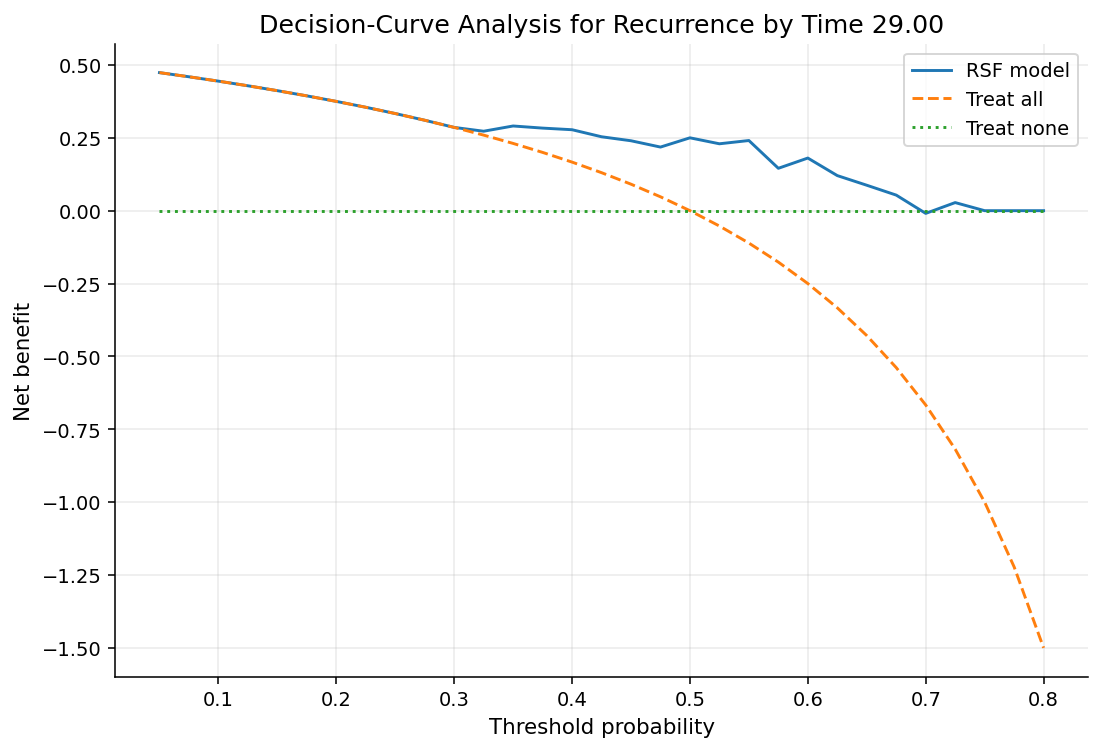

In [40]:
# ============================================================
# CELL 33: Decision-Curve Analysis
# ============================================================

# Binary endpoint: recurrence by calibration_time
dca_df = test_df_cal.copy()
dca_df["event_by_time"] = (
    (dca_df["observed_event"] == 1) &
    (dca_df["observed_time"] <= calibration_time)
).astype(int)

thresholds = np.linspace(0.05, 0.80, 31)
dca_rows = []

N = len(dca_df)
y_true = dca_df["event_by_time"].values
pred_risk = dca_df["predicted_risk"].values

prevalence = y_true.mean()

for pt in thresholds:
    pred_pos = pred_risk >= pt

    TP = np.sum((pred_pos == 1) & (y_true == 1))
    FP = np.sum((pred_pos == 1) & (y_true == 0))

    net_benefit_model = (TP / N) - (FP / N) * (pt / (1 - pt))

    # Treat all
    TP_all = np.sum(y_true == 1)
    FP_all = np.sum(y_true == 0)
    net_benefit_all = (TP_all / N) - (FP_all / N) * (pt / (1 - pt))

    # Treat none
    net_benefit_none = 0.0

    dca_rows.append({
        "Threshold probability": pt,
        "Model net benefit": net_benefit_model,
        "Treat-all net benefit": net_benefit_all,
        "Treat-none net benefit": net_benefit_none,
    })

dca_table = pd.DataFrame(dca_rows)

show_copyable_table(
    dca_table.round(5),
    title="Copyable Table: Decision-Curve Analysis",
    filename="decision_curve_analysis.csv"
)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(dca_table["Threshold probability"], dca_table["Model net benefit"], label="RSF model")
ax.plot(dca_table["Threshold probability"], dca_table["Treat-all net benefit"], linestyle="--", label="Treat all")
ax.plot(dca_table["Threshold probability"], dca_table["Treat-none net benefit"], linestyle=":", label="Treat none")
ax.set_xlabel("Threshold probability")
ax.set_ylabel("Net benefit")
ax.set_title(f"Decision-Curve Analysis for Recurrence by Time {calibration_time:.2f}")
ax.legend()
save_current_figure("decision_curve_analysis")
plt.show()


Copyable Table: RSF Permutation Importance


,Feature,Mean importance,SD importance
1,number,0.11453,0.05770
2,size,0.05798,0.03575
0,treatment_label,0.04782,0.02621



Copyable Markdown table:
| Feature         |   Mean importance |   SD importance |
|:----------------|------------------:|----------------:|
| number          |           0.11453 |         0.0577  |
| size            |           0.05798 |         0.03575 |
| treatment_label |           0.04782 |         0.02621 |

Saved table: outputs_bladder_survival/tables/rsf_permutation_importance.csv
Saved: outputs_bladder_survival/figures/rsf_permutation_importance.png
Saved: outputs_bladder_survival/figures/rsf_permutation_importance.pdf


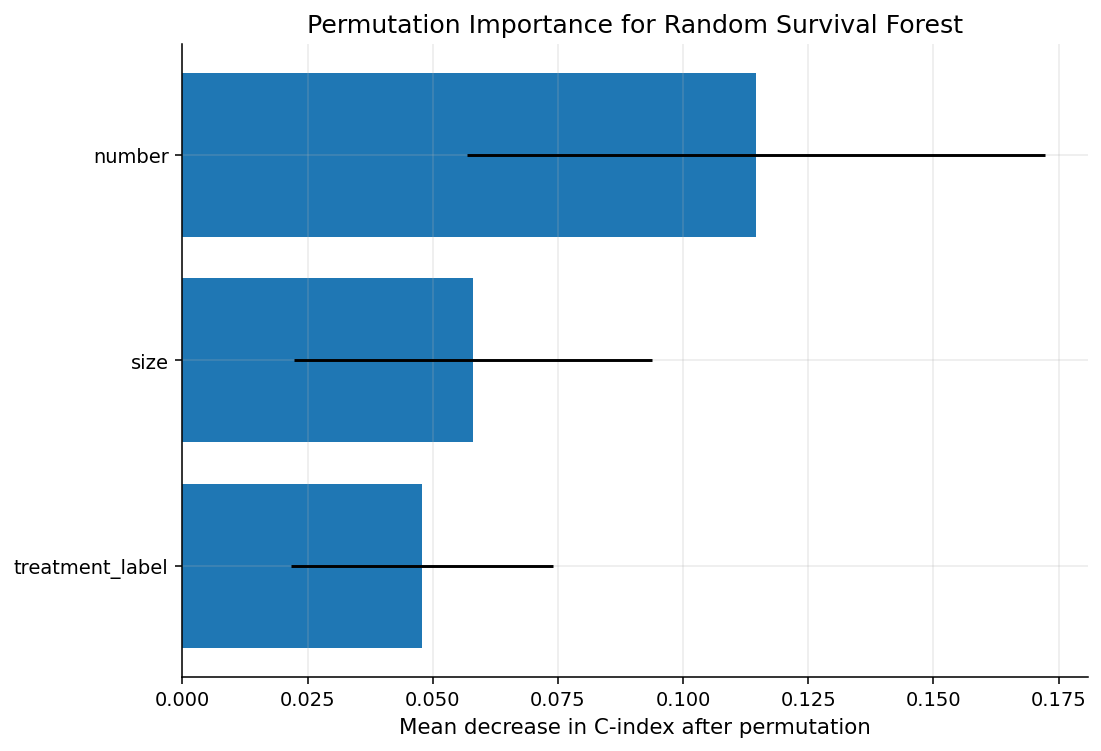

In [41]:
# ============================================================
# CELL 34: Permutation Importance for RSF
# ============================================================

def survival_cindex_scorer(estimator, X_eval, y_eval):
    pred = estimator.predict(X_eval)
    return concordance_index_censored(
        y_eval["event"],
        y_eval["time"],
        pred
    )[0]

perm = permutation_importance(
    rsf,
    X_test,
    y_test,
    scoring=survival_cindex_scorer,
    n_repeats=50,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

perm_table = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean importance": perm.importances_mean,
    "SD importance": perm.importances_std,
}).sort_values("Mean importance", ascending=False)

show_copyable_table(
    perm_table.round(5),
    title="Copyable Table: RSF Permutation Importance",
    filename="rsf_permutation_importance.csv"
)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(perm_table["Feature"], perm_table["Mean importance"], xerr=perm_table["SD importance"])
ax.invert_yaxis()
ax.set_xlabel("Mean decrease in C-index after permutation")
ax.set_title("Permutation Importance for Random Survival Forest")
save_current_figure("rsf_permutation_importance")
plt.show()

In [70]:
# ============================================================
# CELL 35: Prepare Data for PyCox DeepSurv
# Safer version for small dataset
# ============================================================

deep_df = ml_df.copy()

deep_X = pd.get_dummies(
    deep_df[["treatment_label", "number", "size"]],
    drop_first=True
)

scaler = StandardScaler()
deep_X[["number", "size"]] = scaler.fit_transform(deep_X[["number", "size"]])

deep_y_time = deep_df["duration"].astype("float32").values
deep_y_event = deep_df["event"].astype("float32").values

# First split: train-test
X_train_d, X_test_d, y_time_train, y_time_test, y_event_train, y_event_test = train_test_split(
    deep_X.values.astype("float32"),
    deep_y_time,
    deep_y_event,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=deep_df["event"],
)

# Second split: train-validation
# Use a modest validation fraction to avoid very tiny batches.
X_train_d, X_val_d, y_time_train, y_time_val, y_event_train, y_event_val = train_test_split(
    X_train_d,
    y_time_train,
    y_event_train,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_event_train,
)

y_train_d = (y_time_train, y_event_train)
y_val_d = (y_time_val, y_event_val)
y_test_d = (y_time_test, y_event_test)

print("DeepSurv train:", X_train_d.shape)
print("DeepSurv validation:", X_val_d.shape)
print("DeepSurv test:", X_test_d.shape)
print("Features:", list(deep_X.columns))
print("Training events:", int(y_event_train.sum()))
print("Validation events:", int(y_event_val.sum()))
print("Test events:", int(y_event_test.sum()))

DeepSurv train: (61, 4)
DeepSurv validation: (21, 4)
DeepSurv test: (36, 4)
Features: ['number', 'size', 'treatment_label_Pyridoxine', 'treatment_label_Thiotepa']
Training events: 32
Validation events: 11
Test events: 19


In [71]:
# ============================================================
# CELL 36: Train DeepSurv-Style Neural CoxPH Model
# Corrected for small bladder recurrence dataset
# ============================================================

# ------------------------------------------------------------
# Step 1: Define neural CoxPH architecture
# ------------------------------------------------------------

in_features = X_train_d.shape[1]

# Small network because the dataset is small.
# Larger networks can overfit badly here.
num_nodes = [16, 8]

out_features = 1

# Important correction:
# BatchNorm is disabled because small batches may contain only one sample.
batch_norm = False

dropout = 0.10

net = tt.practical.MLPVanilla(
    in_features=in_features,
    num_nodes=num_nodes,
    out_features=out_features,
    batch_norm=batch_norm,
    dropout=dropout,
)

model_deep = PyCoxPH(net, tt.optim.Adam)

# ------------------------------------------------------------
# Step 2: Training settings
# ------------------------------------------------------------

# Use a batch size that is not too large.
# If the final batch has one sample, PyTorch can still train because
# batch normalization is disabled.
batch_size = min(16, max(2, X_train_d.shape[0] // 2))

epochs = 512

callbacks = [
    tt.callbacks.EarlyStopping(patience=25)
]

model_deep.optimizer.set_lr(1e-3)

print("DeepSurv training configuration")
print("--------------------------------")
print("Input features:", in_features)
print("Hidden nodes:", num_nodes)
print("Batch normalization:", batch_norm)
print("Dropout:", dropout)
print("Batch size:", batch_size)
print("Training samples:", X_train_d.shape[0])
print("Validation samples:", X_val_d.shape[0])

# ------------------------------------------------------------
# Step 3: Fit neural CoxPH model
# ------------------------------------------------------------

log = model_deep.fit(
    X_train_d,
    y_train_d,
    batch_size=batch_size,
    epochs=epochs,
    callbacks=callbacks,
    val_data=(X_val_d, y_val_d),
    verbose=True,
)

# ------------------------------------------------------------
# Step 4: Compute baseline hazards
# ------------------------------------------------------------

_ = model_deep.compute_baseline_hazards()

print("DeepSurv-style neural CoxPH training finished.")

DeepSurv training configuration
--------------------------------
Input features: 4
Hidden nodes: [16, 8]
Batch normalization: False
Dropout: 0.1
Batch size: 16
Training samples: 61
Validation samples: 21
0:	[0s / 0s],		train_loss: 2.3017,	val_loss: 2.6001
1:	[0s / 0s],		train_loss: 2.3166,	val_loss: 2.6022
2:	[0s / 0s],		train_loss: 2.2533,	val_loss: 2.6016
3:	[0s / 0s],		train_loss: 2.3042,	val_loss: 2.6018
4:	[0s / 0s],		train_loss: 2.2561,	val_loss: 2.6014
5:	[0s / 0s],		train_loss: 2.3077,	val_loss: 2.5999
6:	[0s / 0s],		train_loss: 2.2414,	val_loss: 2.5995
7:	[0s / 0s],		train_loss: 2.2488,	val_loss: 2.5997
8:	[0s / 0s],		train_loss: 2.3274,	val_loss: 2.5993
9:	[0s / 0s],		train_loss: 2.2266,	val_loss: 2.5982
10:	[0s / 0s],		train_loss: 2.2779,	val_loss: 2.5981
11:	[0s / 0s],		train_loss: 2.2882,	val_loss: 2.5961
12:	[0s / 0s],		train_loss: 2.2272,	val_loss: 2.5968
13:	[0s / 0s],		train_loss: 2.1866,	val_loss: 2.5989
14:	[0s / 0s],		train_loss: 2.1754,	val_loss: 2.6037
15:	[0s / 0

,Epoch,train_loss,val_loss
132,132,2.113604,2.558975
133,133,2.091717,2.560493
134,134,2.107172,2.561401
135,135,2.060375,2.562561
136,136,1.990852,2.564071


Saved: outputs_bladder_survival/figures/deepsurv_training_curve.png
Saved: outputs_bladder_survival/figures/deepsurv_training_curve.pdf


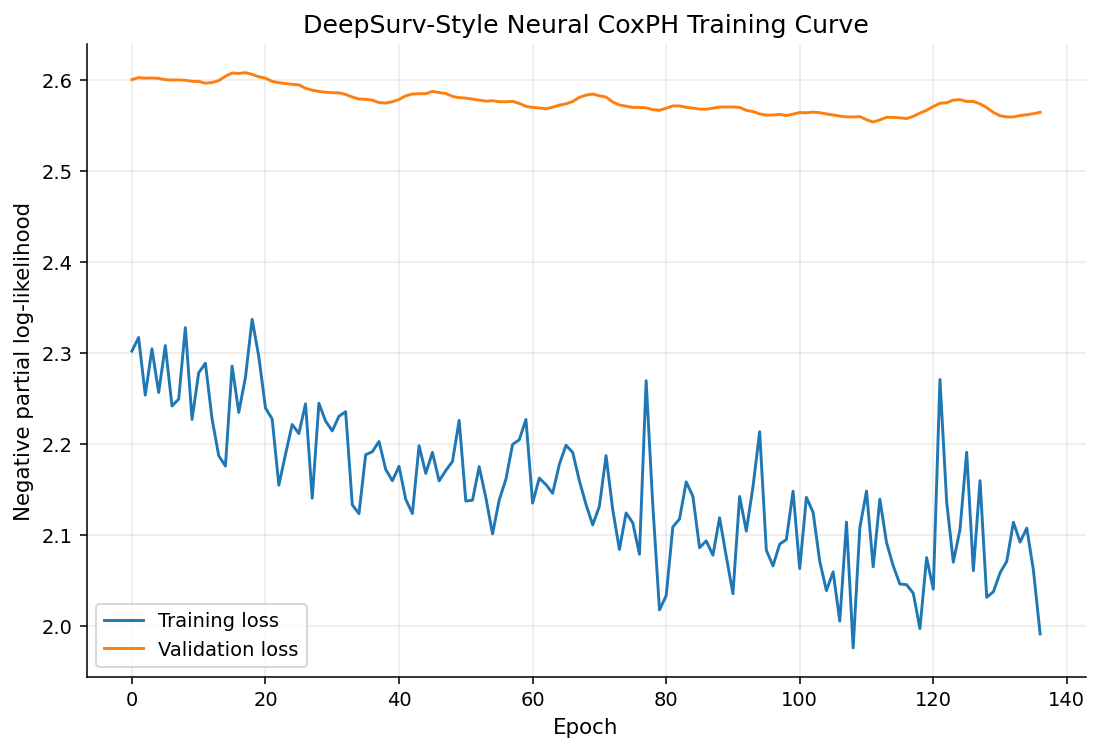


Copyable Table: DeepSurv Training Log


,Epoch,train_loss,val_loss
0,0,2.30168,2.60009
1,1,2.31659,2.60217
2,2,2.25331,2.60163
3,3,2.30417,2.60177
4,4,2.25612,2.60136
5,5,2.30767,2.59995
6,6,2.24135,2.59953
7,7,2.24882,2.59969
8,8,2.32741,2.59932
9,9,2.22661,2.59816



Copyable Markdown table:
|   Epoch |   train_loss |   val_loss |
|--------:|-------------:|-----------:|
|       0 |      2.30168 |    2.60009 |
|       1 |      2.31659 |    2.60217 |
|       2 |      2.25331 |    2.60163 |
|       3 |      2.30417 |    2.60177 |
|       4 |      2.25612 |    2.60136 |
|       5 |      2.30767 |    2.59995 |
|       6 |      2.24135 |    2.59953 |
|       7 |      2.24882 |    2.59969 |
|       8 |      2.32741 |    2.59932 |
|       9 |      2.22661 |    2.59816 |
|      10 |      2.27789 |    2.59806 |
|      11 |      2.28823 |    2.59607 |
|      12 |      2.22716 |    2.59678 |
|      13 |      2.18664 |    2.59892 |
|      14 |      2.17538 |    2.60373 |
|      15 |      2.28522 |    2.60724 |
|      16 |      2.23436 |    2.60682 |
|      17 |      2.27289 |    2.60769 |
|      18 |      2.33657 |    2.60571 |
|      19 |      2.29553 |    2.60314 |

Saved table: outputs_bladder_survival/tables/deepsurv_training_log.csv


In [73]:
# ============================================================
# CELL 37: DeepSurv Training Curve
# ============================================================

log_df = log.to_pandas().reset_index().rename(columns={"index": "Epoch"})

display(log_df.tail())

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(log_df["Epoch"], log_df["train_loss"], label="Training loss")
if "val_loss" in log_df.columns:
    ax.plot(log_df["Epoch"], log_df["val_loss"], label="Validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Negative partial log-likelihood")
ax.set_title("DeepSurv-Style Neural CoxPH Training Curve")
ax.legend()
save_current_figure("deepsurv_training_curve")
plt.show()

show_copyable_table(
    log_df.round(5),
    title="Copyable Table: DeepSurv Training Log",
    filename="deepsurv_training_log.csv",
    max_rows=20
)


Copyable Table: DeepSurv Evaluation


,Model,Test C-index Antolini,Integrated Brier Score
0,DeepSurv-style Neural CoxPH,0.6643,NaN



Copyable Markdown table:
| Model                       |   Test C-index Antolini |   Integrated Brier Score |
|:----------------------------|------------------------:|-------------------------:|
| DeepSurv-style Neural CoxPH |                  0.6643 |                      nan |

Saved table: outputs_bladder_survival/tables/deepsurv_evaluation.csv
Saved: outputs_bladder_survival/figures/deepsurv_predicted_survival_curves.png
Saved: outputs_bladder_survival/figures/deepsurv_predicted_survival_curves.pdf


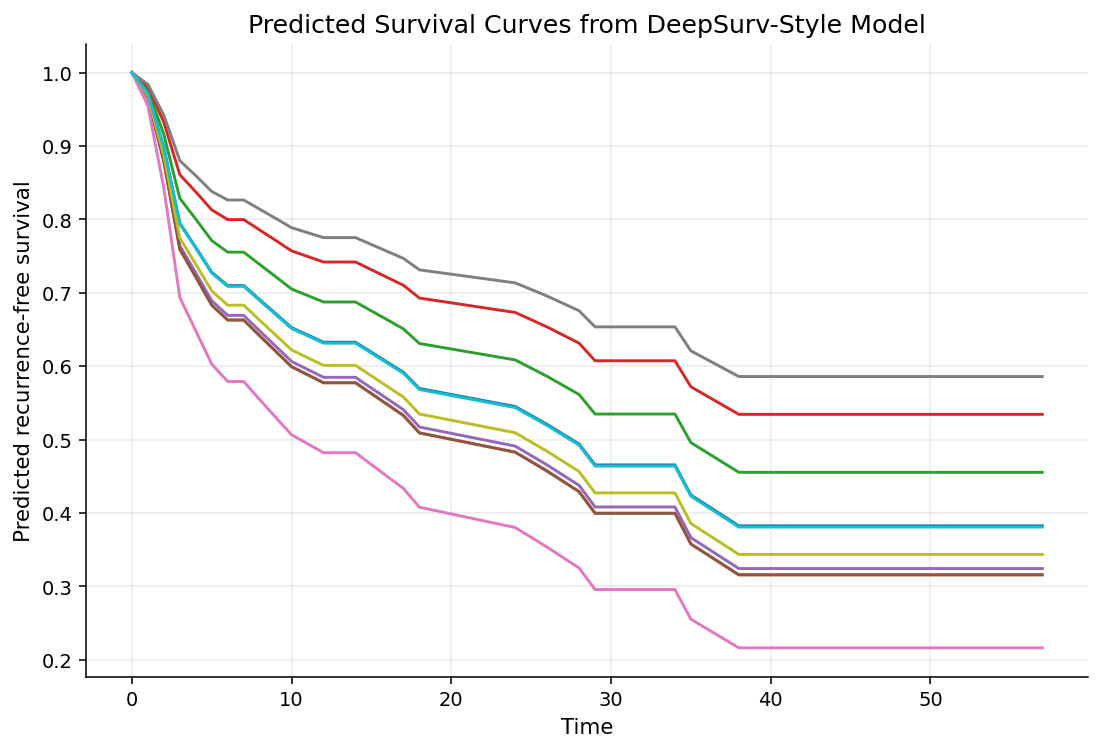

In [74]:
# ============================================================
# CELL 38: Evaluate DeepSurv-Style Neural CoxPH
# ============================================================

surv_deep = model_deep.predict_surv_df(X_test_d)

ev = EvalSurv(
    surv_deep,
    y_time_test,
    y_event_test,
    censor_surv="km",
)

deep_cindex = ev.concordance_td("antolini")

# PyCox integrated Brier score over valid time grid
time_grid = np.linspace(
    np.percentile(y_time_test, 10),
    np.percentile(y_time_test, 90),
    20,
)

try:
    deep_ibs = ev.integrated_brier_score(time_grid)
except Exception:
    deep_ibs = np.nan

deep_results = pd.DataFrame([{
    "Model": "DeepSurv-style Neural CoxPH",
    "Test C-index Antolini": deep_cindex,
    "Integrated Brier Score": deep_ibs,
}])

show_copyable_table(
    deep_results.round(4),
    title="Copyable Table: DeepSurv Evaluation",
    filename="deepsurv_evaluation.csv"
)

fig, ax = plt.subplots(figsize=(8, 5.5))
surv_deep.iloc[:, :min(10, surv_deep.shape[1])].plot(ax=ax, legend=False)
ax.set_title("Predicted Survival Curves from DeepSurv-Style Model")
ax.set_xlabel("Time")
ax.set_ylabel("Predicted recurrence-free survival")
save_current_figure("deepsurv_predicted_survival_curves")
plt.show()

In [75]:
# Part E: Clinical risk stratification


# ============================================================
# CELL 39: Clinical Risk Stratification
# ============================================================

all_rsf_surv = rsf.named_steps["model"].predict_survival_function(
    rsf.named_steps["preprocess"].transform(X)
)

all_risk = 1 - survival_at_time(all_rsf_surv, risk_time)

risk_df = firstrec.loc[ml_df.index].copy()
risk_df["rsf_predicted_risk"] = all_risk

risk_df["risk_group"] = pd.qcut(
    risk_df["rsf_predicted_risk"],
    q=3,
    labels=["Low risk", "Intermediate risk", "High risk"],
    duplicates="drop",
)

risk_group_summary = (
    risk_df
    .groupby("risk_group")
    .agg(
        patients=("id", "nunique"),
        mean_predicted_risk=("rsf_predicted_risk", "mean"),
        observed_recurrence_rate=("event", "mean"),
        median_duration=("duration", "median"),
        mean_total_recurrences=("total_recurrences", "mean"),
    )
    .reset_index()
)

risk_group_summary["observed_recurrence_percent"] = 100 * risk_group_summary["observed_recurrence_rate"]

show_copyable_table(
    risk_group_summary.round(4),
    title="Copyable Table: Clinical Risk Groups",
    filename="clinical_risk_groups.csv"
)


Copyable Table: Clinical Risk Groups


,risk_group,patients,mean_predicted_risk,observed_recurrence_rate,median_duration,mean_total_recurrences,observed_recurrence_percent
0,Low risk,40,0.3799,0.3000,25.5,0.9000,30.0000
1,Intermediate risk,49,0.5711,0.5714,10.0,1.8367,57.1429
2,High risk,29,0.7259,0.7586,5.0,2.1724,75.8621



Copyable Markdown table:
| risk_group        |   patients |   mean_predicted_risk |   observed_recurrence_rate |   median_duration |   mean_total_recurrences |   observed_recurrence_percent |
|:------------------|-----------:|----------------------:|---------------------------:|------------------:|-------------------------:|------------------------------:|
| Low risk          |         40 |                0.3799 |                     0.3    |              25.5 |                   0.9    |                       30      |
| Intermediate risk |         49 |                0.5711 |                     0.5714 |              10   |                   1.8367 |                       57.1429 |
| High risk         |         29 |                0.7259 |                     0.7586 |               5   |                   2.1724 |                       75.8621 |

Saved table: outputs_bladder_survival/tables/clinical_risk_groups.csv


Saved: outputs_bladder_survival/figures/km_by_model_derived_risk_group.png
Saved: outputs_bladder_survival/figures/km_by_model_derived_risk_group.pdf


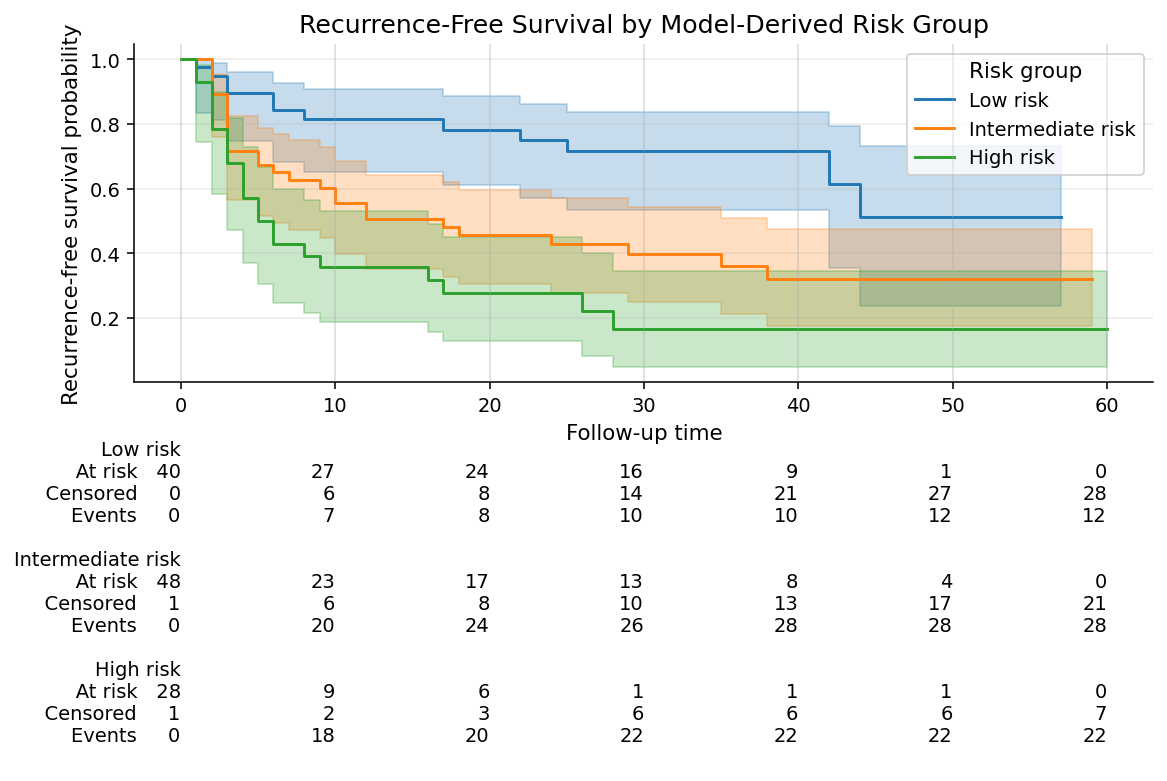


Copyable Table: Logrank Test Across Model-Derived Risk Groups


,Comparison,Test statistic,p-value,Degrees of freedom
0,Risk groups,18.54784,0.00009,2



Copyable Markdown table:
| Comparison   |   Test statistic |   p-value |   Degrees of freedom |
|:-------------|-----------------:|----------:|---------------------:|
| Risk groups  |          18.5478 |     9e-05 |                    2 |

Saved table: outputs_bladder_survival/tables/risk_group_logrank_test.csv


In [47]:
# ============================================================
# CELL 40: KM Curves by Model-Derived Risk Group
# ============================================================

risk_km_models = {}

fig, ax = plt.subplots(figsize=(8.5, 6))

for group, g in risk_df.groupby("risk_group", observed=True):
    kmf = KaplanMeierFitter()
    kmf.fit(g["duration"], g["event"], label=str(group))
    kmf.plot_survival_function(ax=ax)
    risk_km_models[str(group)] = kmf

ax.set_title("Recurrence-Free Survival by Model-Derived Risk Group")
ax.set_xlabel("Follow-up time")
ax.set_ylabel("Recurrence-free survival probability")
ax.legend(title="Risk group")
add_at_risk_counts(*risk_km_models.values(), ax=ax)
save_current_figure("km_by_model_derived_risk_group")
plt.show()

risk_logrank = multivariate_logrank_test(
    risk_df["duration"],
    risk_df["risk_group"].astype(str),
    risk_df["event"],
)

risk_logrank_table = pd.DataFrame([{
    "Comparison": "Risk groups",
    "Test statistic": risk_logrank.test_statistic,
    "p-value": risk_logrank.p_value,
    "Degrees of freedom": risk_logrank.degrees_of_freedom,
}])

show_copyable_table(
    risk_logrank_table.round(5),
    title="Copyable Table: Logrank Test Across Model-Derived Risk Groups",
    filename="risk_group_logrank_test.csv"
)


Copyable Table: Final Model Comparison


,Model,Primary evaluation,Value,Interpretation
0,CoxPH / Penalized Cox,Test C-index,0.6925,Interpretable semi-parametric survival model
1,Elastic-net Coxnet,Test C-index,0.6901,Regularized linear survival model
2,Random Survival Forest,Test C-index,0.7148,Nonlinear ensemble survival model
3,DeepSurv-style Neural CoxPH,Antolini C-index,0.6643,Exploratory neural survival model; use cautiou...
4,Random Survival Forest,Integrated Brier Score,0.3078,Lower is better; assesses survival probability...



Copyable Markdown table:
| Model                       | Primary evaluation     |   Value | Interpretation                                                   |
|:----------------------------|:-----------------------|--------:|:-----------------------------------------------------------------|
| CoxPH / Penalized Cox       | Test C-index           |  0.6925 | Interpretable semi-parametric survival model                     |
| Elastic-net Coxnet          | Test C-index           |  0.6901 | Regularized linear survival model                                |
| Random Survival Forest      | Test C-index           |  0.7148 | Nonlinear ensemble survival model                                |
| DeepSurv-style Neural CoxPH | Antolini C-index       |  0.6643 | Exploratory neural survival model; use cautiously for small data |
| Random Survival Forest      | Integrated Brier Score |  0.3078 | Lower is better; assesses survival probability accuracy          |

Saved table: outputs_bladder_surviv

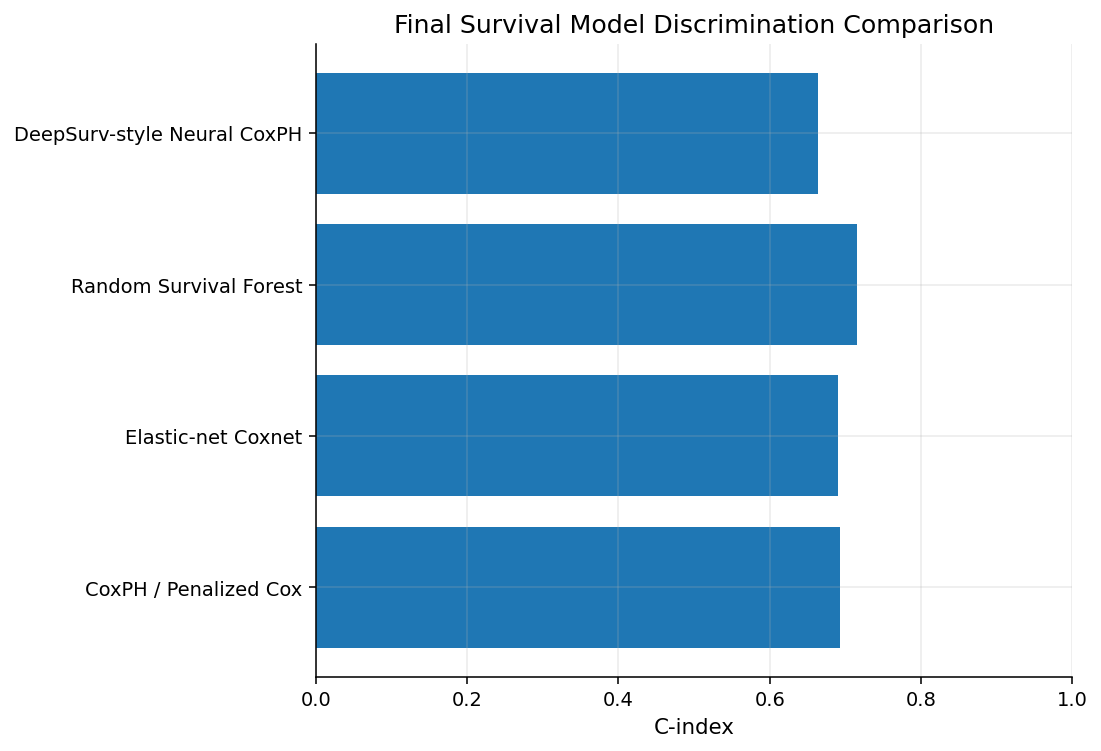

In [76]:
# Part F: Final model comparison and export

# ============================================================
# CELL 41: Final Model Comparison
# ============================================================

# CoxPH train/test split evaluation using original cox_df
cox_eval_df = cox_df.copy()

cox_train_df, cox_test_df = train_test_split(
    cox_eval_df,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=cox_eval_df["event"],
)

cox_eval = CoxPHFitter(penalizer=float(best_pen))
cox_eval.fit(cox_train_df, duration_col="duration", event_col="event")

cox_risk_test = cox_eval.predict_partial_hazard(cox_test_df).values.ravel()
cox_test_cindex = concordance_index(
    cox_test_df["duration"],
    -cox_risk_test,
    cox_test_df["event"],
)

final_model_table = pd.DataFrame([
    {
        "Model": "CoxPH / Penalized Cox",
        "Primary evaluation": "Test C-index",
        "Value": cox_test_cindex,
        "Interpretation": "Interpretable semi-parametric survival model",
    },
    {
        "Model": "Elastic-net Coxnet",
        "Primary evaluation": "Test C-index",
        "Value": coxnet_test_c,
        "Interpretation": "Regularized linear survival model",
    },
    {
        "Model": "Random Survival Forest",
        "Primary evaluation": "Test C-index",
        "Value": rsf_test_score,
        "Interpretation": "Nonlinear ensemble survival model",
    },
    {
        "Model": "DeepSurv-style Neural CoxPH",
        "Primary evaluation": "Antolini C-index",
        "Value": deep_cindex,
        "Interpretation": "Exploratory neural survival model; use cautiously for small data",
    },
    {
        "Model": "Random Survival Forest",
        "Primary evaluation": "Integrated Brier Score",
        "Value": rsf_ibs,
        "Interpretation": "Lower is better; assesses survival probability accuracy",
    },
])

show_copyable_table(
    final_model_table.round(4),
    title="Copyable Table: Final Model Comparison",
    filename="final_model_comparison.csv"
)

fig, ax = plt.subplots(figsize=(8, 5.5))
plot_final = final_model_table[
    final_model_table["Primary evaluation"].str.contains("C-index", case=False, regex=False)
].copy()

ax.barh(plot_final["Model"], plot_final["Value"])
ax.set_xlabel("C-index")
ax.set_title("Final Survival Model Discrimination Comparison")
ax.set_xlim(0, 1)
save_current_figure("final_model_cindex_comparison")
plt.show()

In [77]:
# ============================================================
# CELL 42: Save Models and Processed Data
# ============================================================

import joblib

joblib.dump(cph, MODEL_DIR / "coxph_lifelines_model.joblib")
joblib.dump(cph_pen, MODEL_DIR / "penalized_cox_lifelines_model.joblib")
joblib.dump(rsf, MODEL_DIR / "random_survival_forest_pipeline.joblib")
joblib.dump(coxnet, MODEL_DIR / "coxnet_survival_pipeline.joblib")
joblib.dump(scaler, MODEL_DIR / "deepsurv_scaler.joblib")

# Save PyTorch/PyCox neural model weights
torch.save(model_deep.net.state_dict(), MODEL_DIR / "deepsurv_neural_coxph_state_dict.pt")

firstrec.to_csv(TABLE_DIR / "final_first_recurrence_patient_level_data.csv", index=False)
risk_df.to_csv(TABLE_DIR / "final_patient_risk_stratification.csv", index=False)
ag_model_df.to_csv(TABLE_DIR / "final_anderson_gill_recurrent_event_data.csv", index=False)

print("Models and processed data saved.")

Models and processed data saved.


In [78]:
# ============================================================
# CELL 43: Zip All Outputs
# ============================================================

import shutil

zip_path = shutil.make_archive(
    base_name="bladder_survival_ai_outputs",
    format="zip",
    root_dir=OUTPUT_DIR,
)

print("Created ZIP archive:", zip_path)

try:
    from google.colab import files
    files.download(zip_path)
except Exception:
    print("Download available at:", zip_path)

Created ZIP archive: /content/bladder_survival_ai_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [79]:
# Part G: Suggested EUO reporting text


# ============================================================
# CELL 44: Manuscript-Ready Result Summary
# ============================================================

best_cindex_row = final_model_table[
    final_model_table["Primary evaluation"].str.contains("C-index", case=False, regex=False)
].sort_values("Value", ascending=False).iloc[0]

summary_text = f"""
Suggested Results Summary

The analysis included {firstrec['id'].nunique()} patients from the bladder cancer recurrence dataset.
The primary endpoint was time to first recurrence, and the secondary endpoint was recurrent-event burden.
Kaplan–Meier curves were used to describe recurrence-free survival across treatment groups.
Cox proportional hazards regression and Anderson–Gill recurrent-event modeling were used for interpretable survival analysis.
Machine-learning survival models included penalized Cox, Random Survival Forest, and a DeepSurv-style neural CoxPH model.

Among the discrimination-oriented models, the highest C-index was observed for:
{best_cindex_row['Model']} with {best_cindex_row['Primary evaluation']} = {best_cindex_row['Value']:.3f}.

The Random Survival Forest additionally produced an integrated Brier score of {rsf_ibs:.3f}.
Model-derived low-, intermediate-, and high-risk groups were created using predicted recurrence risk at time {risk_time:.2f}.
These risk groups should be interpreted as exploratory because the dataset is small, historical, and externally unvalidated.

Suggested EUO Article Type:
Research Letter first. Original Article only if expanded with an external bladder cancer cohort such as TCGA-BLCA or an institutional validation cohort.
"""

print(summary_text)

with open(OUTPUT_DIR / "manuscript_ready_summary.txt", "w") as f:
    f.write(summary_text)


Suggested Results Summary

The analysis included 118 patients from the bladder cancer recurrence dataset.
The primary endpoint was time to first recurrence, and the secondary endpoint was recurrent-event burden.
Kaplan–Meier curves were used to describe recurrence-free survival across treatment groups.
Cox proportional hazards regression and Anderson–Gill recurrent-event modeling were used for interpretable survival analysis.
Machine-learning survival models included penalized Cox, Random Survival Forest, and a DeepSurv-style neural CoxPH model.

Among the discrimination-oriented models, the highest C-index was observed for:
Random Survival Forest with Test C-index = 0.715.

The Random Survival Forest additionally produced an integrated Brier score of 0.308.
Model-derived low-, intermediate-, and high-risk groups were created using predicted recurrence risk at time 29.00.
These risk groups should be interpreted as exploratory because the dataset is small, historical, and externally un